# Output integrity and physical consistency (regional run): `tas`, `tasmax`, `tasmin`, `dtr`, `pr`, `rsds`, `hurs`

Production's three QA/QC parts run against the *regional (wide)* run: output integrity
([#450](https://github.com/carbonplan/srm-downscaling/issues/450)), temperature ordering `tasmin ≤ tas ≤ tasmax` ([#448](https://github.com/carbonplan/srm-downscaling/issues/448)), precipitation
constraints ([#459](https://github.com/carbonplan/srm-downscaling/issues/459)).

Lat -38 to -19, lon 13 to 36 (southern Africa, both oceans); one icechunk store per GCM on branch
`full-regional-run-issue-534`; every scenario, variable and member. `CESM2-WACCM` alone also carries
`g6_1p5k_end`, the termination-shock run (member `002`, 2085-2100). Scratch-bucket check, not a
production artifact.

Five checks production's notebook lacks, none of them re-reading the stores:

| Check | Question |
| --- | --- |
| 1b | Does a leaf have a `NaN` its neighbors don't? |
| 6 | Are the leaves distinct from one another? |
| 7 | Is the expected set of leaves present? |
| 8 | Is each time axis complete? |
| 9 | Is every leaf on the grid it should be? |

In [1]:
import functools
import itertools
import operator
import os
from collections import defaultdict

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
import coiled
import dask
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shapely
import xarray as xr
import zarr
from dask_array.xarray import register
from IPython.display import display

from srm.config import ClusterConfig
from srm.qaqc import VAR_SPATIAL_RANGES, highlight
from srm.validation import _open_output_datatree, resolve_member_time_bounds

os.environ["FRISKY_SUMMARY"] = "off"
from frisky import hijack

# Activate frisky's query-optimized dask array backend for xarray before opening any store,
# so every array uses one backend (see https://matthewrocklin.com/frisky-xarray/).
register()

zarr.config.set({"async.concurrency": 128})

# --- Run parameters: one icechunk store per GCM, same branch, small spatial subset ---
BUCKET = "carbonplan-srm"
BRANCH = "full-regional-run-issue-534"
# s3://carbonplan-srm/scratch/output/qa/{GCM}-ERA5-lat-38.0to-19.0_lon13.0to36.0.icechunk (branch:full-regional-run-issue-534)
PREFIXES = {
    "CESM2-WACCM": "scratch/output/qa/CESM2-WACCM-ERA5-lat-38.0to-19.0_lon13.0to36.0.icechunk",
    "MIROC-ES2H": "scratch/output/qa/MIROC-ES2H-ERA5-lat-38.0to-19.0_lon13.0to36.0.icechunk",
    "UKESM": "scratch/output/qa/UKESM-ERA5-lat-38.0to-19.0_lon13.0to36.0.icechunk",
}
GCMS = list(PREFIXES)
SPATIAL = ["lat", "lon"]

## Compute

Bucket and cluster both in `us-west-2`. The box is 77 x 93 cells against production's 721 x 1440,
but ~12x the earlier `lat -31..-26, lon 23..30` box, so the cluster sits between the two.

In [2]:
# ~12x the cells of the earlier regional box, so the worker ceiling is raised to match.
cfg = ClusterConfig(n_workers=[4, 20])
cluster = coiled.Cluster(
    name="srm-qaqc-output-checks-regional",
    region=cfg.region,
    n_workers=cfg.n_workers,
    worker_vm_types=["r8gn.xlarge", "r8gn.2xlarge"],
    scheduler_vm_types=["c8g.large"],
    spot_policy="spot_with_fallback",
    use_best_zone=True,
    tags=cfg.tags,
)
client = hijack(cluster.get_client())
client

Output()

╭──────────────────────────────── Package Info ────────────────────────────────╮
│                    ╷                                                         │
│   Package          │ Note                                                    │
│ ╶──────────────────┼───────────────────────────────────────────────────────╴ │
│   coiled_local_src │ Wheel built from                                        │
│                    │ /scratch/coiled-senv-spec/wheels/coiled_local_src/coi   │
│                    │ led_local_src-0.0.0-py3-none-any.whl                    │
│   srm              │ Wheel built from                                        │
│                    │ /scratch/coiled-senv-spec/wheels/srm/srm-0.13.0.post1   │
│                    │ 1+g4a1bce801-py3-none-any.whl                           │
│                    ╵                                                         │
╰──────────────────────────────────────────────────────────────────────────────╯

Output()

2026-08-07 21:29:22,861 - distributed.deploy.adaptive - INFO - Adaptive scaling started: minimum=4 maximum=20


## The output store layout

One store per GCM, versioned by branch rather than by path. `historical`, `ssp245` and `g6_1p5k`
(plus `g6_1p5k_end` on CESM2-WACCM) hold fine-grid output; `debiased_coarse/…` holds coarse output
on the GCM grid. Each `(gcm, family, scenario, variable, member)` path is one leaf, checked
independently.

In [3]:
# Iterates GCMS, not PREFIXES, so trimming GCMS scales the run down without opening extra
# stores.
trees: dict[str, xr.DataTree] = {
    gcm: _open_output_datatree(f"s3://{BUCKET}/{PREFIXES[gcm]}", branch=BRANCH) for gcm in GCMS
}
trees[GCMS[0]]

<xarray.DataTree>
Group: /
├── Group: /debiased_coarse
│   ├── Group: /debiased_coarse/g6_1p5k
│   │   ├── Group: /debiased_coarse/g6_1p5k/dtr
│   │   │   ├── Group: /debiased_coarse/g6_1p5k/dtr/001
│   │   │   │       Dimensions:  (time: 18263, lat: 20, lon: 18)
│   │   │   │       Coordinates:
│   │   │   │         * time     (time) datetime64[ns] 146kB 2035-01-01 2035-01-02 ... 2084-12-31
│   │   │   │         * lat      (lat) float64 160B -37.23 -36.28 -35.34 ... -21.2 -20.26 -19.32
│   │   │   │         * lon      (lon) float64 144B 13.75 15.0 16.25 17.5 ... 31.25 32.5 33.75 35.0
│   │   │   │       Data variables:
│   │   │   │           dtr      (time, lat, lon) float32 26MB dask.array<open_dataset-dtr, shape...
│   │   │   │       Attributes: (12/17)
│   │   │   │           Conventions:                                 CF-1.8
│   │   │   │           institution:                                 CarbonPlan
│   │   │   │           history:                                     2026-08-05T07:32:10Z: BCSD d...
│   │   │   │           srm_downscaling:version:                     0.12.0.post17+g1393b8301.d20...
│   │   │   │           srm_downscaling:gcm:                         CESM2-WACCM
│   │   │   │           srm_downscaling:scenario:                    G6-1.5K
│   │   │   │           ...                                          ...
│   │   │   │           srm_downscaling:bias_correction_method:      nonparametric_hybrid_2sided
│   │   │   │           srm_downscaling:downscaling_method:          multiplicative
│   │   │   │           srm_downscaling:train_period:                1978-2014
│   │   │   │           srm_downscaling:config_hash:                 c26d582759c4
│   │   │   │           srm_downscaling:config_json:                 {"gcm":"CESM2-WACCM","variab...
│   │   │   │           srm_downscaling:creation_date:               2026-08-05
│   │   │   ├── Group: /debiased_coarse/g6_1p5k/dtr/003
│   │   │   │       Dimensions:  (time: 18263, lat: 20, lon: 18)
│   │   │   │       Coordinates:
│   │   │   │         * time     (time) datetime64[ns] 146kB 2035-01-01 2035-01-02 ... 2084-12-31
│   │   │   │         * lat      (lat) float64 160B -37.23 -36.28 -35.34 ... -21.2 -20.26 -19.32
│   │   │   │         * lon      (lon) float64 144B 13.75 15.0 16.25 17.5 ... 31.25 32.5 33.75 35.0
│   │   │   │       Data variables:
│   │   │   │           dtr      (time, lat, lon) float32 26MB dask.array<open_dataset-dtr, shape...
│   │   │   │       Attributes: (12/17)
│   │   │   │           Conventions:                                 CF-1.8
│   │   │   │           institution:                                 CarbonPlan
│   │   │   │           history:                                     2026-08-05T07:32:09Z: BCSD d...
│   │   │   │           srm_downscaling:version:                     0.12.0.post17+g1393b8301.d20...
│   │   │   │           srm_downscaling:gcm:                         CESM2-WACCM
│   │   │   │           srm_downscaling:scenario:                    G6-1.5K
│   │   │   │           ...                                          ...
│   │   │   │           srm_downscaling:bias_correction_method:      nonparametric_hybrid_2sided
│   │   │   │           srm_downscaling:downscaling_method:          multiplicative
│   │   │   │           srm_downscaling:train_period:                1978-2014
│   │   │   │           srm_downscaling:config_hash:                 dd215e17ef98
│   │   │   │           srm_downscaling:config_json:                 {"gcm":"CESM2-WACCM","variab...
│   │   │   │           srm_downscaling:creation_date:               2026-08-05
│   │   │   └── Group: /debiased_coarse/g6_1p5k/dtr/002
│   │   │           Dimensions:  (time: 18263, lat: 20, lon: 18)
│   │   │           Coordinates:
│   │   │             * time     (time) datetime64[ns] 146kB 2035-01-01 2035-01-02 ... 2084-12-31
│   │   │             * lat      (lat) float64 160B -37.23 -36.28 -35.34 ... -21.2 -20.26 -19.32
│   │   │             * lon     

In [4]:
SCENARIO_LABELS = {
    "historical": "historical",
    "ssp245": "SSP245",
    "g6_1p5k": "G6-1.5K",
    "g6_1p5k_end": "G6-1.5K-END",  # CESM2-WACCM only: the termination-shock run
}
GROUP_TO_SCENARIO = {
    **SCENARIO_LABELS,
    **{f"debiased_coarse/{g}": label for g, label in SCENARIO_LABELS.items()},
}


def group_leaves(gcm: str, group: str) -> dict[tuple[str, str, str, str], xr.DataArray]:
    """One lazy DataArray per (gcm, group, variable, member); variables come from the tree."""
    node = trees[gcm][group]
    return {
        (gcm, group, v, m): node[f"{v}/{m}"].dataset[v]
        for v in node.children
        for m in node[v].children
    }


def has_group(gcm: str, group: str) -> bool:
    """Whether a store carries a group: only CESM2-WACCM has g6_1p5k_end."""
    node = trees[gcm]
    for part in group.split("/"):
        if part not in node.children:
            return False
        node = node[part]
    return True


leaves: dict[tuple[str, str, str, str], xr.DataArray] = {}
for gcm in GCMS:
    for group in GROUP_TO_SCENARIO:
        if has_group(gcm, group):
            leaves.update(group_leaves(gcm, group))


def table(rows: dict) -> pd.DataFrame:
    """One row per leaf, indexed by (gcm, scenario, variable, member).

    The MultiIndex is built explicitly: pandas only infers one from tuple keys when there's a
    row.
    """
    df = pd.DataFrame.from_dict(rows, orient="index")
    df.index = pd.MultiIndex.from_tuples(
        rows.keys(), names=["gcm", "scenario", "variable", "member"]
    )
    return df


print(f"{len(leaves)} (gcm, scenario, variable, member) leaves to check")

644 (gcm, scenario, variable, member) leaves to check


### A note on member coverage

`CESM2-WACCM` only: `tas`, `pr` and `rsds` use ESM labels (`r1i1p1f1`, …) historically and numeric
ids (`003`, …) for scenarios, while `tasmax`/`tasmin` come from a corrected run stored as member
`001` historically (a known CMIP6 bug, see `srm.lineage`). Hence no Part 2 triplet for its
historical period. MIROC-ES2H and UKESM share one historical id across all three temperature
variables, so theirs are checkable.

## Part 1: output integrity (issue #450)

Production's five checks (NaNs, duplicate time slices, all-zero timesteps, physical ranges, time
coverage), computed once per leaf and batched by `(gcm, scenario group)` so no dask graph spans a
whole store. See [#450](https://github.com/carbonplan/srm-downscaling/issues/450).

In [5]:
def leaf_stats(da: xr.DataArray) -> xr.Dataset:
    """Lazy per-leaf reductions, fused into one pass over each array on compute."""
    return xr.Dataset(
        {
            # Per-cell NaN count: the total is Check 1, the map lets Check 1b tell the regrid
            # border from a real interior gap.
            "nan_days": da.isnull().sum("time"),
            "min": da.min(),
            "max": da.max(),
            # Per-day spatial moments, reused by Checks 2, 3, 5 and 6. Four independent moments
            # identify a duplicate day without a second read of the array.
            "fingerprint": xr.concat(
                [da.min(SPATIAL), da.max(SPATIAL), da.mean(SPATIAL), da.std(SPATIAL)],
                dim=pd.Index(["min", "max", "mean", "std"], name="stat"),
            ),
        }
    )

### Check 1: no NaNs

Fails any leaf carrying a `NaN`. On a subset that is every fine-grid leaf: downscaling leaves an
always-`NaN` border where the interpolation buffer runs off the box, and `debiased_coarse` is
unaffected. Kept for comparison with production; Check 1b is what enters the headline.

In [6]:
def check_no_nans(stats: dict) -> pd.DataFrame:
    """Total NaN cell-days per leaf; pass = zero."""
    nan_df = table({k: {"n_nan_cell_days": int(s.nan_days.sum())} for k, s in stats.items()})
    nan_df["pass"] = nan_df.n_nan_cell_days == 0
    return nan_df

### Check 1b: no NaNs outside the interpolation border - "missing data (spatial completeness)"

Re-runs Check 1 with the shared border masked, so the question becomes whether a leaf has a `NaN`
its neighbors don't. The border is the cells `NaN` on every day of *every* leaf on a grid, never
per leaf: a per-leaf border would be self-fulfilling, since an always-`NaN` hole from a real bug
would define itself as border and pass.

In [7]:
def family_of(group: str) -> str:
    """Which of the two grids a leaf lives on."""
    return "debiased_coarse" if group.startswith("debiased_coarse") else "fine"


def structural_border(stats: dict, leaves: dict) -> dict[tuple[str, str], xr.DataArray]:
    """Per (gcm, family): cells NaN on every day of every leaf on that grid."""
    grids: dict[tuple[str, str], list] = defaultdict(list)
    for k, s in stats.items():
        grids[(k[0], family_of(k[1]))].append(s.nan_days == leaves[k].sizes["time"])
    return {key: functools.reduce(operator.and_, masks) for key, masks in grids.items()}


def check_interior_nans(stats: dict, leaves: dict) -> pd.DataFrame:
    """NaN cell-days outside the structural border; pass = zero."""
    borders = structural_border(stats, leaves)
    interior_df = table(
        {
            k: {
                "n_nan_cells": int((s.nan_days > 0).sum()),  # cells NaN on at least one day
                "n_nan_cell_days": int(s.nan_days.sum()),  # scales with record length
                "interior_nan_cell_days": int(
                    s.nan_days.where(~borders[(k[0], family_of(k[1]))], 0).sum()
                ),
            }
            for k, s in stats.items()
        }
    )
    interior_df["pass"] = interior_df.interior_nan_cell_days == 0
    return interior_df

### Check 2: no duplicate time slices

Two identical days mean a write error, a chunk dated wrong or a step run twice. Pairwise comparison
scales quadratically, so each day is reduced to a fingerprint (spatial min, max, mean, std) and days
sharing one are grouped. Four independent moments make a collision effectively impossible, so a
shared fingerprint is reported without a confirming read.

Every `pr` leaf failed this on the earlier, much smaller box, where whole-domain dry days share one
all-zero fingerprint. This box is 12x larger and reaches two oceans, and every `pr` leaf passes. The
failure was the region's size, not the pipeline.

In [8]:
def duplicate_pairs(fp: xr.DataArray) -> list[tuple[str, str]]:
    """Day-pairs sharing an identical (min, max, mean, std) spatial fingerprint.

    A shared fingerprint is reported directly: four independent moments make a collision between
    two genuinely different fields effectively impossible, and confirming it costs a second pass.
    """
    arr = fp.transpose("time", "stat").values
    valid = ~np.isnan(arr).any(axis=1)
    times = fp.time.values[valid]

    _, inv = np.unique(arr[valid], axis=0, return_inverse=True)
    groups: dict[int, list[np.datetime64]] = {}
    for t, g in zip(times, inv):
        groups.setdefault(int(g), []).append(t)

    def fmt(t: np.datetime64) -> str:
        return str(np.datetime_as_string(t, unit="D"))

    return [(fmt(g[0]), fmt(t)) for g in groups.values() if len(g) > 1 for t in g[1:]]


def check_no_duplicates(stats: dict) -> pd.DataFrame:
    dup_df = table(
        {k: {"duplicate_pairs": duplicate_pairs(s.fingerprint)} for k, s in stats.items()}
    )
    dup_df["pass"] = dup_df.duplicate_pairs.str.len() == 0
    return dup_df

### Check 3: reasonable ranges

Each leaf's global min and max against `VAR_SPATIAL_RANGES` (`srm.qaqc`), the wide input-data bounds
from [#316](https://github.com/carbonplan/srm-downscaling/issues/316); a value well outside them is more often a unit error than weather. Days whose
spatial extreme passes 65 °C or −100 °C are reported rather than failed, since one implausible cell
is worth seeing but does not invalidate an array.

Two limits on what this can say:

- The bounds are global, so a value ordinary globally but impossible locally passes (25 °C in
  Antarctic winter). [plausible-value-check.ipynb](plausible-value-check.ipynb) is the location- and
  season-aware complement.
- `rsds` is allowed down to −1 W m⁻² rather than strict non-negativity, since downscaled shortwave
  was slightly negative in ERA5. Only this global-extreme test watches for it; `pr` gets the
  per-cell, per-day equivalent in Part 3.

In [9]:
TEMP_VARS = {"tas", "tasmax", "tasmin"}
HOT_K = 65 + 273.15  # outlandishly_high_temp threshold (srm.qaqc)
COLD_K = -100 + 273.15  # outlandishly_low_temp threshold (srm.qaqc)


def irregular_days(v: str, fp: xr.DataArray) -> list[tuple[str, float]]:
    """(date, K) for days whose spatial max/min breaches the outlandish temp thresholds."""
    if v not in TEMP_VARS:
        return []
    smax = fp.sel(stat="max")
    smin = fp.sel(stat="min")
    bad = ((smax > HOT_K) | (smin < COLD_K)).values
    times = fp.time.values[bad]
    vals = smax.where(smax > HOT_K, smin).values[bad]  # report whichever extreme tripped
    return [(str(t)[:10], round(float(x), 1)) for t, x in zip(times, vals)]


def check_reasonable_ranges(stats: dict) -> pd.DataFrame:
    range_df = table(
        {
            k: {
                "min": float(s["min"]),
                "max": float(s["max"]),
                "irregular_days": irregular_days(k[2], s["fingerprint"]),
            }
            for k, s in stats.items()
        }
    )
    range_df["pass"] = [
        VAR_SPATIAL_RANGES[v]["min"][0] <= mn <= VAR_SPATIAL_RANGES[v]["min"][1]
        and VAR_SPATIAL_RANGES[v]["max"][0] <= mx <= VAR_SPATIAL_RANGES[v]["max"][1]
        for (gcm, s, v, m), mn, mx in zip(range_df.index, range_df["min"], range_df["max"])
    ]
    range_df["n_irregular_days"] = range_df.irregular_days.str.len()
    return range_df

### Check 4: within input time bounds - "missing data (temporal completeness)"

Each leaf's first and last timestamp against `resolve_member_time_bounds(gcm, scenario, member)`,
with no exemptions. `bridged_pre_sai` and `stale_end_tail` are production's regression-guard
sentinels. Check 8 covers what happens between the endpoints.

In [10]:
def check_time_bounds(leaves: dict) -> pd.DataFrame:
    bounds_df = table(
        {
            (gcm, s, v, m): {
                "actual_start": str(da.time.values[0])[:10],
                "actual_end": str(da.time.values[-1])[:10],
                "n_time": da.sizes["time"],
                "expected": resolve_member_time_bounds(gcm, GROUP_TO_SCENARIO[s], m),
            }
            for (gcm, s, v, m), da in leaves.items()
        }
    )
    expected_start = bounds_df.expected.str[0].fillna("0000-01-01")  # no known bounds -> pass
    expected_end = bounds_df.expected.str[1].fillna("9999-12-31")
    is_sai = bounds_df.index.get_level_values("scenario").str.upper().str.contains("G6|SAI")
    starts_before_raw = bounds_df.actual_start < expected_start
    ends_after_raw = bounds_df.actual_end > expected_end
    # Production's sentinels: bridged_pre_sai for a SAI leaf starting before its raw input bound,
    # stale_end_tail for a leaf running past it. No exemptions.
    bounds_df["bridged_pre_sai"] = is_sai & starts_before_raw
    bounds_df["stale_end_tail"] = ends_after_raw
    bounds_df["pass"] = ~starts_before_raw & ~ends_after_raw
    return bounds_df

### Check 5: no all-zero timesteps

A field identically zero across the whole domain is a write or masking error, not weather (#425).
Any day whose fingerprint min and max are both exactly zero is flagged, `pr` included: individual
cells are legitimately zero, a whole correct global field is not.

That does not hold on a small, semi-arid box, where domain-wide dry days are real and tripped
Check 2 for the same reason. On this box no leaf has an all-zero day.

In [11]:
def all_zero_days(fp: xr.DataArray) -> list[str]:
    """Dates whose entire spatial field is exactly 0 (spatial min and max both 0) -- see #425."""
    smin = fp.sel(stat="min")
    smax = fp.sel(stat="max")
    bad = ((smin == 0) & (smax == 0)).values
    return [str(t)[:10] for t in fp.time.values[bad]]


def check_no_all_zero(stats: dict) -> pd.DataFrame:
    """Per-leaf list of all-zero global days; pass = none."""
    zero_df = table(
        {k: {"all_zero_days": all_zero_days(s["fingerprint"])} for k, s in stats.items()}
    )
    zero_df["pass"] = zero_df.all_zero_days.str.len() == 0
    return zero_df

### Check 6: no duplicate leaves - "are all output files different from each other?"

Two leaves on the same grid should never hold the same data: a member written from another's source,
a variable written into another's path, or a scenario written straight from the run it branches out
of would all pass every check above. Check 2's fingerprint is compared across every pair in a
`(gcm, family)`, and a pair is reported when all four moments agree on every day the two share.

Scope is the family, not the scenario group, and the comparison is on the shared window, not
xarray's `equals`. The narrow version could not reach this run's likeliest duplications:

- `equals` compares coordinates too, so it never pairs leaves on different axes, and CESM2-WACCM's
  `ssp245` alone carries two axis lengths (19,724 and 31,046 steps).
- Grouping by scenario kept a `g6_1p5k` leaf from meeting the `ssp245` leaf it may have been bridged
  from ([#448](https://github.com/carbonplan/srm-downscaling/issues/448)), and `g6_1p5k_end` from meeting the `g6_1p5k` run it branches out of.

Each pair carries its shared window and whether that window is the whole of each leaf's record.
Nothing is dropped for being short, since a partial match is a finding rather than a lesser one.
Overlap indices are cached per axis pair and each pair is screened on its first shared day, so the
wider scope costs less than the narrow one did.

In [12]:
def _equal_nan(a: np.ndarray, b: np.ndarray) -> bool:
    """Elementwise equality treating NaN as matching NaN, as xarray's ``equals`` does.

    The fine grid's border is NaN in every leaf, so a strict ``==`` would stop real duplicates
    pairing.
    """
    return bool(np.array_equal(a, b, equal_nan=True))


def duplicate_leaves(stats: dict) -> list[tuple]:
    """Leaf pairs whose fingerprints agree on every shared day, within one (gcm, family).

    Returns (leaf, leaf, start, end, n_overlap, full_a, full_b); each ``full_x`` says whether the
    shared window is the whole of that leaf's record. Overlap indices are cached per axis pair,
    since alignment is a property of the axes and not of the leaves.
    """
    by_family: dict[tuple[str, str], list] = defaultdict(list)
    for k in stats:
        by_family[(k[0], family_of(k[1]))].append(k)

    pairs = []
    for keys in by_family.values():
        fps = {k: stats[k].fingerprint.transpose("time", "stat").values for k in keys}
        times = {k: stats[k].fingerprint.time.values for k in keys}
        # Axis identity, so leaves on the same time coordinate share one intersection.
        axes = {k: times[k].tobytes() for k in keys}
        overlaps: dict[tuple[bytes, bytes], tuple] = {}

        for a, b in itertools.combinations(keys, 2):
            axis_pair = (axes[a], axes[b])
            if axis_pair not in overlaps:
                # Time coordinates are unique and sorted, so intersect1d's indices are exact.
                overlaps[axis_pair] = np.intersect1d(times[a], times[b], return_indices=True)
            shared, ia, ib = overlaps[axis_pair]
            if not len(shared):
                continue  # disjoint records can't be duplicates of one another
            fa, fb = fps[a], fps[b]
            # Screen on the first shared day: four comparisons reject essentially every pair.
            if not _equal_nan(fa[ia[0]], fb[ib[0]]) or not _equal_nan(fa[ia], fb[ib]):
                continue
            pairs.append(
                (
                    a,
                    b,
                    str(shared[0])[:10],
                    str(shared[-1])[:10],
                    len(shared),
                    len(shared) == len(times[a]),
                    len(shared) == len(times[b]),
                )
            )
    return pairs

### Check 7: expected inventory - "basic file checks (presence/absence of expected variables)"

Leaves come from the tree, so anything never written is absent from the tables above rather than
failing them. `EXPECTED` is hand-built from `configs/qa/**/*southafrica.yaml`, not from
`srm.lineage`, which would check the pipeline against its own metadata. Members are listed per
variable because CESM2-WACCM's coverage genuinely differs between them. A second diff compares each
store's groups against the ones expected for that GCM.

In [13]:
ALL_VARS = ["tas", "tasmax", "tasmin", "dtr", "pr", "rsds", "hurs"]
CESM_HIST = ["r1i1p1f1", "r2i1p1f1", "r3i1p1f1"]
CESM_SSP = [f"{i:03d}" for i in range(1, 11)]
MIROC_HIST = ["r1i1p4f2", "r2i1p4f2", "r3i1p4f2"]
MIROC_SSP = [f"r{i:02d}" for i in range(1, 11)]
UKESM_MEMBERS = ["r2i1p1f2", "r3i1p1f2", "r12i1p1f2"]

# From configs/qa/**/*southafrica.yaml, applied to both families. Historical ids are the parent
# members those configs resolve to, which differ from the scenario ids for CESM2-WACCM and MIROC.
EXPECTED: dict[tuple[str, str], dict[str, list[str]]] = {
    ("CESM2-WACCM", "historical"): {
        "tas": CESM_HIST,
        "pr": CESM_HIST,
        "rsds": CESM_HIST,
        "hurs": CESM_HIST,
        "tasmax": ["001"],
        "tasmin": ["001"],
        "dtr": ["001"],
    },
    ("CESM2-WACCM", "ssp245"): {
        "tas": CESM_SSP,
        "pr": CESM_SSP,
        "rsds": CESM_SSP,
        "hurs": CESM_SSP,
        "tasmax": CESM_SSP[5:],
        "tasmin": CESM_SSP[5:],
        "dtr": CESM_SSP[5:],
    },
    ("CESM2-WACCM", "g6_1p5k"): {v: ["001", "002", "003"] for v in ALL_VARS},
    ("CESM2-WACCM", "g6_1p5k_end"): {v: ["002"] for v in ALL_VARS},
    ("MIROC-ES2H", "historical"): {v: MIROC_HIST for v in ALL_VARS},
    ("MIROC-ES2H", "ssp245"): {v: MIROC_SSP for v in ALL_VARS},
    ("MIROC-ES2H", "g6_1p5k"): {v: MIROC_SSP for v in ALL_VARS},
    ("UKESM", "historical"): {v: UKESM_MEMBERS for v in ALL_VARS},
    ("UKESM", "ssp245"): {v: UKESM_MEMBERS for v in ALL_VARS},
    ("UKESM", "g6_1p5k"): {v: UKESM_MEMBERS for v in ALL_VARS},
}


def pair_table(rows: dict, names: list[str]) -> pd.DataFrame:
    """Two-level table for the checks that report per grid or per group, not per leaf."""
    df = pd.DataFrame.from_dict(rows, orient="index")
    df.index = pd.MultiIndex.from_tuples(rows.keys(), names=names)
    return df


def check_inventory(leaves: dict) -> pd.DataFrame:
    """Observed (variable, member) leaves vs EXPECTED, per (gcm, scenario group)."""
    observed: dict[tuple[str, str], set] = defaultdict(set)
    for gcm, group, v, m in leaves:
        observed[(gcm, group)].add((v, m))
    rows = {}
    for (gcm, group), obs in sorted(observed.items()):
        expected = {
            (v, m) for v, members in EXPECTED[(gcm, group.split("/")[-1])].items() for m in members
        }
        rows[(gcm, group)] = {
            "n_expected": len(expected),
            "n_observed": len(obs),
            "missing": sorted(expected - obs),
            "unexpected": sorted(obs - expected),
        }
    df = pair_table(rows, ["gcm", "group"])
    df["pass"] = (df.missing.str.len() == 0) & (df.unexpected.str.len() == 0)
    return df


def check_groups(trees: dict) -> pd.DataFrame:
    """Groups present in each store vs the ones expected for that GCM.

    Expectations come from EXPECTED's keys, not SCENARIO_LABELS: only CESM2-WACCM has
    g6_1p5k_end.
    """
    rows = {}
    for gcm, tree in trees.items():
        expected = {scenario for expected_gcm, scenario in EXPECTED if expected_gcm == gcm}
        families = {
            "fine": set(tree.children) - {"debiased_coarse"},
            "debiased_coarse": set(tree["debiased_coarse"].children)
            if "debiased_coarse" in tree.children
            else set(),
        }
        for family, found in families.items():
            rows[(gcm, family)] = {
                "groups": sorted(found),
                "missing": sorted(expected - found),
                "unchecked": sorted(found - expected),
            }
    df = pair_table(rows, ["gcm", "family"])
    df["pass"] = (df.missing.str.len() == 0) & (df.unchecked.str.len() == 0)
    return df

### Check 8: regular time axis - "missing data (temporal completeness)"

A missing day, or one written twice, leaves Check 4's endpoints intact. Every span here is a
Gregorian daily record (1978-2014 is 13,514 steps), so one distinct 1-day step across the axis is
the complete statement, and a single positive step is monotonic by construction.

In [14]:
def check_time_axis(leaves: dict) -> pd.DataFrame:
    """One uniform 1-day step per leaf; catches gaps and repeats Check 4's endpoints can't see."""
    rows = {}
    for k, da in leaves.items():
        # pd.Timedelta normalizes resolution: a raw timedelta64[ns] step converts back to an int
        # and would never compare equal.
        steps = [pd.Timedelta(s) for s in np.unique(np.diff(da.time.values))]
        rows[k] = {
            "n_time": da.sizes["time"],
            "distinct_steps": [str(s) for s in steps],
            "pass": steps == [pd.Timedelta(days=1)],
        }
    return table(rows)

### Check 9: grid consistency - "dimensional checks (e.g. expected data shape)"

One row per `(gcm, family)`, since the grid belongs to the family rather than to any one leaf. Every
fine leaf should sit on the same 77 x 93 grid, `lat -38.0` to `-19.0` and `lon 13.0` to `36.0`,
matching the run's `subset_bounds`; each GCM's `debiased_coarse` leaves should share that GCM's
native grid. Two grids in one family means leaves were written against different targets.

In [15]:
FINE_SHAPE = (77, 93)
FINE_LAT = (-38.0, -19.0)
FINE_LON = (13.0, 36.0)


def check_grids(leaves: dict) -> pd.DataFrame:
    """One grid per (gcm, family), and the fine family on the run's subset_bounds."""
    grids: dict[tuple[str, str], set] = defaultdict(set)
    for k, da in leaves.items():
        grids[(k[0], family_of(k[1]))].add(
            (
                (da.sizes["lat"], da.sizes["lon"]),
                (round(float(da.lat[0]), 4), round(float(da.lat[-1]), 4)),
                (round(float(da.lon[0]), 4), round(float(da.lon[-1]), 4)),
            )
        )
    rows = {}
    for key, found in sorted(grids.items()):
        shape, lat_span, lon_span = sorted(found)[0]
        rows[key] = {
            "n_distinct_grids": len(found),
            "shape": shape,
            "lat_span": lat_span,
            "lon_span": lon_span,
        }
    df = pair_table(rows, ["gcm", "family"])
    is_fine = df.index.get_level_values("family") == "fine"
    on_subset_bounds = (
        df["shape"].map(lambda s: s == FINE_SHAPE)
        & df.lat_span.map(lambda s: s == FINE_LAT)
        & df.lon_span.map(lambda s: s == FINE_LON)
    )
    df["pass"] = (df.n_distinct_grids == 1) & (~is_fine | on_subset_bounds)
    return df

### Running the checks

Per-leaf stats one `(gcm, scenario group)` at a time across several small `dask.compute` calls, then
every check against the collected summaries. Part 3's precip counts ride along in the same pass.

Every check table below is colored by `srm.qaqc.highlight`: green where the column's condition
holds, red where it fails, amber for the two that are flagged without being defects
(`n_irregular_days`, which Check 3 reports rather than fails, and `no_nans`, demoted here because
every fine-grid leaf fails it on the interpolation border).

In [16]:
%%time

# Per-leaf reductions, batched by (gcm, scenario group) so no dask graph spans every leaf. Part
# 3's precip counts ride along, so each pr array is read once here rather than again later.
PR_OUTLANDISH = 2000 / 86400  # 2000 mm/day in kg m-2 s-1 (~0.02315); largest recorded ~1825 mm/day


def pr_physical(da: xr.DataArray) -> xr.Dataset:
    """Per-cell day counts for the Part-3 precip checks, folded into the Part-1 read."""
    return xr.Dataset(
        {
            "neg_days": (da < 0).sum("time"),  # non-negativity: expected 0 everywhere
            "high_days": (da > PR_OUTLANDISH).sum("time"),  # outlandish daily total
        },
        attrs={"n_time": da.sizes["time"]},
    )


def compute_with_retry(*collections, attempts=3, label=""):
    """dask.compute with retries so a transient scheduler glitch does not abort the whole run."""
    import time

    for attempt in range(1, attempts + 1):
        try:
            return dask.compute(*collections)
        except Exception as exc:
            if attempt == attempts:
                raise
            print(f"    {label}retry {attempt}/{attempts - 1} after {type(exc).__name__}")
            time.sleep(5)


# Each group computes independently: a transient failure retries, and a group that still fails is
# skipped so the rest of the notebook runs on what did compute.
stats: dict = {}
pr_phys: dict = {}
failed_groups: list[tuple[str, str]] = []
for gcm in GCMS:
    for group in GROUP_TO_SCENARIO:
        g_leaves = {k: da for k, da in leaves.items() if k[0] == gcm and k[1] == group}
        if not g_leaves:
            continue
        try:
            s, p = compute_with_retry(
                {k: leaf_stats(da) for k, da in g_leaves.items()},
                {k: pr_physical(da) for k, da in g_leaves.items() if k[2] == "pr"},
                label=f"[{gcm}/{group}] ",
            )
        except Exception as exc:
            failed_groups.append((gcm, group))
            print(
                f"  {gcm}/{group}: FAILED after retries ({type(exc).__name__}); continuing with the rest"
            )
            continue
        stats.update(s)
        pr_phys.update(p)
        print(f"  {gcm}/{group}: {len(s)} leaves computed")

if failed_groups:
    print(
        f"\n!! groups that did not compute: {failed_groups} -- rerun those before trusting results"
    )

# A failed group is absent from every check rather than crashing the notebook. Coordinate-only
# checks (4, 7, 8, 9) are restricted the same way.
computed = {k: leaves[k] for k in stats}
nan_df = check_no_nans(stats)
interior_df = check_interior_nans(stats, computed)
dup_df = check_no_duplicates(stats)
zero_df = check_no_all_zero(stats)
range_df = check_reasonable_ranges(stats)
bounds_df = check_time_bounds(computed)
dupe_pairs = duplicate_leaves(stats)
inventory_df = check_inventory(computed)
groups_df = check_groups(trees)
time_axis_df = check_time_axis(computed)
grid_df = check_grids(computed)

summary = pd.concat(
    {
        "no_nans": nan_df["pass"],
        "no_interior_nans": interior_df["pass"],
        "no_duplicate_timesteps": dup_df["pass"],
        "no_all_zero_days": zero_df["pass"],
        "reasonable_range": range_df["pass"],
        "n_irregular_days": range_df["n_irregular_days"],
        "within_input_time_bounds": bounds_df["pass"],
        "bridged_pre_sai": bounds_df["bridged_pre_sai"],
        "stale_end_tail": bounds_df["stale_end_tail"],
        "regular_time_axis": time_axis_df["pass"],
    },
    axis=1,
)
# no_nans is amber rather than red here: on a subset it fails structurally, not from a defect
# (same reason it is left out of check_cols below).
display(highlight(summary, demote=["no_nans"]))

# no_nans is deliberately absent: every fine-grid leaf fails it on the interpolation border, and
# Check 1b is the informative version here.
check_cols = [
    "no_interior_nans",
    "no_duplicate_timesteps",
    "no_all_zero_days",
    "reasonable_range",
    "within_input_time_bounds",
    "regular_time_axis",
]
print(
    f"\nAll per-leaf checks pass across {len(summary)} leaves: {bool(summary[check_cols].all().all())}"
)

tb_fail = ~summary["within_input_time_bounds"]
known = summary["bridged_pre_sai"] | summary["stale_end_tail"]
print(
    f"within_input_time_bounds failures: {int(tb_fail.sum())} "
    f"(g6 bridge: {int(summary['bridged_pre_sai'].sum())}, "
    f"stale end tail: {int(summary['stale_end_tail'].sum())}; "
    f"all known: {bool((tb_fail == known).all())})"
)
other_cols = ["no_interior_nans", "no_duplicate_timesteps", "no_all_zero_days", "reasonable_range"]
print(f"All other per-leaf checks pass on every leaf: {bool(summary[other_cols].all().all())}")

  CESM2-WACCM/historical: 15 leaves computed
  CESM2-WACCM/ssp245: 55 leaves computed
  CESM2-WACCM/g6_1p5k: 21 leaves computed
  CESM2-WACCM/g6_1p5k_end: 7 leaves computed
  CESM2-WACCM/debiased_coarse/historical: 15 leaves computed
  CESM2-WACCM/debiased_coarse/ssp245: 55 leaves computed
  CESM2-WACCM/debiased_coarse/g6_1p5k: 21 leaves computed
  CESM2-WACCM/debiased_coarse/g6_1p5k_end: 7 leaves computed
  MIROC-ES2H/historical: 21 leaves computed
  MIROC-ES2H/ssp245: 70 leaves computed
  MIROC-ES2H/g6_1p5k: 70 leaves computed
  MIROC-ES2H/debiased_coarse/historical: 21 leaves computed
  MIROC-ES2H/debiased_coarse/ssp245: 70 leaves computed
  MIROC-ES2H/debiased_coarse/g6_1p5k: 70 leaves computed
  UKESM/historical: 21 leaves computed
  UKESM/ssp245: 21 leaves computed
  UKESM/g6_1p5k: 21 leaves computed
  UKESM/debiased_coarse/historical: 21 leaves computed
  UKESM/debiased_coarse/ssp245: 21 leaves computed
  UKESM/debiased_coarse/g6_1p5k: 21 leaves computed



All per-leaf checks pass across 644 leaves: True
within_input_time_bounds failures: 0 (g6 bridge: 0, stale end tail: 0; all known: True)
All other per-leaf checks pass on every leaf: True
CPU times: user 28.5 s, sys: 424 ms, total: 29 s
Wall time: 3min 29s


A clean store: no interior `NaN`s, no duplicated days, no all-zero fields, in-range values. Expect
Check 1 to fail on every fine-grid leaf and Checks 2/5 to flag any `pr` leaf with a domain-wide dry
day; 1b, 3, 4 and 7-9 should pass.

Read Check 6 rather than assume it. Its scope now spans scenarios, so a `g6_1p5k` leaf bridged from
`ssp245`, or a `g6_1p5k_end` leaf matching the `g6_1p5k` run it branches from, surfaces as a
partial-window pair.

In [17]:
# Any leaf with NaNs fails Check 1.
print(f"Leaves with any NaN: {int((nan_df.n_nan_cell_days > 0).sum())}")

# Any leaf with an all-zero global timestep fails Check 5 (#425).
zero_flagged = zero_df[~zero_df["pass"]]
if len(zero_flagged):
    print("\nAll-zero timesteps (Check 5 failure, #425):")
    for (gcm, s, v, m), row in zero_flagged.iterrows():
        print(f"  {gcm}/{s}/{v}/{m}: {len(row.all_zero_days)} days -- e.g. {row.all_zero_days[:5]}")
else:
    print("\nNo all-zero timesteps flagged.")

# Dates and values for any leaf with implausible single-day spikes.
flagged = range_df[range_df.n_irregular_days > 0]
if len(flagged):
    print("\nIrregular days (report-only, spatial extreme past 65C / -100C):")
    for (gcm, s, v, m), row in flagged.iterrows():
        print(f"  {gcm}/{s}/{v}/{m}: {row.n_irregular_days} days")
        for date, k in row.irregular_days:
            print(f"    {date}  {k}K ({k - 273.15:.1f}C)")
else:
    print("\nNo irregular days flagged.")

Leaves with any NaN: 322

No all-zero timesteps flagged.

No irregular days flagged.


### Checks 6-9 and the NaN border

The per-grid and per-group checks, plus the border Check 1b masked off. `border_frac` well above
zero on the fine family and exactly zero on `debiased_coarse` is the interpolation buffer's
signature.

In [18]:
# n_nan_cells distribution per family, then the border it comes from (Check 1b). Both
# post-process the in-memory nan_days maps: no reads.
family = interior_df.index.get_level_values("scenario").map(family_of).rename("family")
print("Cells NaN on at least one day, per leaf, by grid family:")
print(interior_df.n_nan_cells.groupby(family).describe().to_string(), "\n")

print("Structural NaN border, per (gcm, family):")
for (gcm, family), border in structural_border(stats, computed).items():
    print(
        f"  {gcm}/{family}: {int(border.sum())}/{border.size} cells "
        f"always NaN in every leaf (border_frac {float(border.mean()):.3f})"
    )
print(f"\nLeaves with interior NaNs (Check 1b failure): {int((~interior_df['pass']).sum())}")

print(f"\nDuplicate leaf pairs (Check 6): {len(dupe_pairs)}")
for a, b, start, end, n_overlap, full_a, full_b in dupe_pairs:
    # "full" on both sides is a straight duplicate; on one side only it's a shorter leaf
    # contained in a longer one, the shape a bridged or branched scenario takes.
    tags = ("full" if full_a else "partial", "full" if full_b else "partial")
    print(f"  {'/'.join(a)} ({tags[0]})  ==  {'/'.join(b)} ({tags[1]})")
    print(f"      shared {start} to {end}, {n_overlap} days")

print("\nExpected inventory (Check 7):")
display(highlight(inventory_df))
print("Store groups vs the ones checked (Check 7):")
display(highlight(groups_df))
print("Grids (Check 9):")
display(highlight(grid_df))

print(
    "\nChecks 6-9 all pass: "
    f"{not dupe_pairs and bool(inventory_df['pass'].all()) and bool(groups_df['pass'].all()) and bool(grid_df['pass'].all()) and bool(time_axis_df['pass'].all())}"
)

Cells NaN on at least one day, per leaf, by grid family:
                 count         mean         std     min     25%     50%     75%     max
family                                                                                 
debiased_coarse  322.0     0.000000    0.000000     0.0     0.0     0.0     0.0     0.0
fine             322.0  1365.608696  210.023828  1055.0  1055.0  1477.0  1533.0  1533.0 

Structural NaN border, per (gcm, family):
  CESM2-WACCM/fine: 1055/7161 cells always NaN in every leaf (border_frac 0.147)
  CESM2-WACCM/debiased_coarse: 0/360 cells always NaN in every leaf (border_frac 0.000)
  MIROC-ES2H/fine: 1533/7161 cells always NaN in every leaf (border_frac 0.214)
  MIROC-ES2H/debiased_coarse: 0/208 cells always NaN in every leaf (border_frac 0.000)
  UKESM/fine: 1421/7161 cells always NaN in every leaf (border_frac 0.198)
  UKESM/debiased_coarse: 0/180 cells always NaN in every leaf (border_frac 0.000)

Leaves with interior NaNs (Check 1b failure): 0

Dupl

Store groups vs the ones checked (Check 7):


Grids (Check 9):



Checks 6-9 all pass: True


### Time coverage per leaf

Each leaf's real first and last day, `n_time`, expected bounds, and the two sentinels. Per GCM,
since member ids and their bounds differ by GCM.

In [19]:
# Each leaf keeps its own real extent: no shared, padded axis.
coverage_cols = [
    "actual_start",
    "actual_end",
    "n_time",
    "expected",
    "bridged_pre_sai",
    "stale_end_tail",
]
display(highlight(bounds_df[coverage_cols]))

## Part 2: temperature ordering consistency (issue #448)

`tasmin ≤ tas ≤ tasmax` should hold. `tasmax ≥ tasmin` is enforced by post-processing
([#331](https://github.com/carbonplan/srm-downscaling/issues/331)) and should hold everywhere; `tasmax ≥ tas` and `tasmin ≤ tas` are unguaranteed and
only measured.

### Assembling comparable triplets

Members carrying `tas`, `tasmax` and `tasmin` together, intersected within each `(gcm, group)`. This
excludes CESM2-WACCM's historical period, per the member-coverage note above.

In [20]:
%%time


def temperature_triplets(leaves: dict) -> list[tuple[str, str, str]]:
    """(gcm, family/scenario group, member) paths that carry tas AND tasmax AND tasmin."""
    have: dict[tuple[str, str, str], set[str]] = {}
    for gcm, group, v, m in leaves:
        have.setdefault((gcm, group, m), set()).add(v)
    return sorted(gm for gm, vs in have.items() if TEMP_VARS <= vs)


def ordering_violations(gcm: str, group: str, member: str) -> xr.Dataset:
    """Per-cell count of days each ordering rule is broken, for one triplet.

    The three variables can cover different spans within one member, so they are inner-joined on
    time first.
    """
    node = trees[gcm][group]
    tas = node[f"tas/{member}"].dataset["tas"]
    tasmax = node[f"tasmax/{member}"].dataset["tasmax"]
    tasmin = node[f"tasmin/{member}"].dataset["tasmin"]
    tas, tasmax, tasmin = xr.align(tas, tasmax, tasmin, join="inner")
    return xr.Dataset(
        {
            "max_lt_min": (tasmax < tasmin).sum("time"),  # expected 0 (#331 post-processing)
            "max_lt_tas": (tasmax < tas).sum("time"),  # diagnostic (#448)
            "min_gt_tas": (tasmin > tas).sum("time"),  # diagnostic (#448)
        },
        attrs={"n_time": tas.sizes["time"]},
    )


triplets = temperature_triplets(leaves)
print("Checkable (gcm, group, member) triplets:")
for gcm, g, m in triplets:
    print(f"  {gcm}/{g}/{m}")

viol = compute_with_retry({gm: ordering_violations(*gm) for gm in triplets}, label="[part2] ")[0]

Checkable (gcm, group, member) triplets:
  CESM2-WACCM/debiased_coarse/g6_1p5k/001
  CESM2-WACCM/debiased_coarse/g6_1p5k/002
  CESM2-WACCM/debiased_coarse/g6_1p5k/003
  CESM2-WACCM/debiased_coarse/g6_1p5k_end/002
  CESM2-WACCM/debiased_coarse/ssp245/006
  CESM2-WACCM/debiased_coarse/ssp245/007
  CESM2-WACCM/debiased_coarse/ssp245/008
  CESM2-WACCM/debiased_coarse/ssp245/009
  CESM2-WACCM/debiased_coarse/ssp245/010
  CESM2-WACCM/g6_1p5k/001
  CESM2-WACCM/g6_1p5k/002
  CESM2-WACCM/g6_1p5k/003
  CESM2-WACCM/g6_1p5k_end/002
  CESM2-WACCM/ssp245/006
  CESM2-WACCM/ssp245/007
  CESM2-WACCM/ssp245/008
  CESM2-WACCM/ssp245/009
  CESM2-WACCM/ssp245/010
  MIROC-ES2H/debiased_coarse/g6_1p5k/r01
  MIROC-ES2H/debiased_coarse/g6_1p5k/r02
  MIROC-ES2H/debiased_coarse/g6_1p5k/r03
  MIROC-ES2H/debiased_coarse/g6_1p5k/r04
  MIROC-ES2H/debiased_coarse/g6_1p5k/r05
  MIROC-ES2H/debiased_coarse/g6_1p5k/r06
  MIROC-ES2H/debiased_coarse/g6_1p5k/r07
  MIROC-ES2H/debiased_coarse/g6_1p5k/r08
  MIROC-ES2H/debiased

### Violation frequencies

Days where `tasmax < tasmin` (expected zero), and for the two unguaranteed relationships the cells
violated on at least one day with the domain fraction they represent. That fraction saturates toward
one over a long record, so the maps and area-weighted table below read severity more fairly.

In [21]:
def consistency_summary(viol: dict) -> pd.DataFrame:
    rows = {}
    for (gcm, group, m), ds in viol.items():
        rows[(gcm, group, m)] = {
            "n_time": ds.attrs["n_time"],
            "days_max<min": int(ds.max_lt_min.sum()),  # #331 guarantee: should be 0
            "cells_max<tas": int((ds.max_lt_tas > 0).sum()),
            "frac_cells_max<tas": round(float((ds.max_lt_tas > 0).mean()), 5),
            "cells_min>tas": int((ds.min_gt_tas > 0).sum()),
            "frac_cells_min>tas": round(float((ds.min_gt_tas > 0).mean()), 5),
        }
    # Build the MultiIndex explicitly (see `table`'s docstring).
    df = pd.DataFrame.from_dict(rows, orient="index")
    df.index = pd.MultiIndex.from_tuples(rows.keys(), names=["gcm", "group", "member"])
    return df


consistency_df = consistency_summary(viol)
display(highlight(consistency_df))

n_regressions = int(consistency_df["days_max<min"].sum())
print(
    f"\ntasmax >= tasmin holds everywhere (#331): {n_regressions == 0} "
    f"(total offending days across triplets: {n_regressions})"
)


tasmax >= tasmin holds everywhere (#331): True (total offending days across triplets: 0)


### Where the ordering breaks

Fraction of days `tasmax < tas` and `tasmin > tas` per triplet, masking cells that never violate;
pale means the ordering almost always holds. The box reaches both coasts, so it includes the
Benguela upwelling where production's global maps show the largest effect, but carries no high
latitudes, so the polar half of that pattern is absent.

/opt/coiled/env/lib/python3.13/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


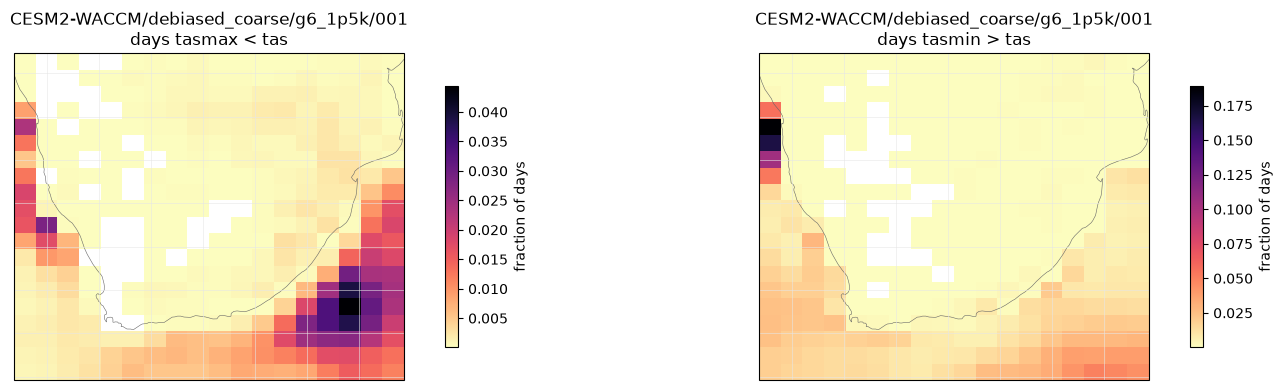

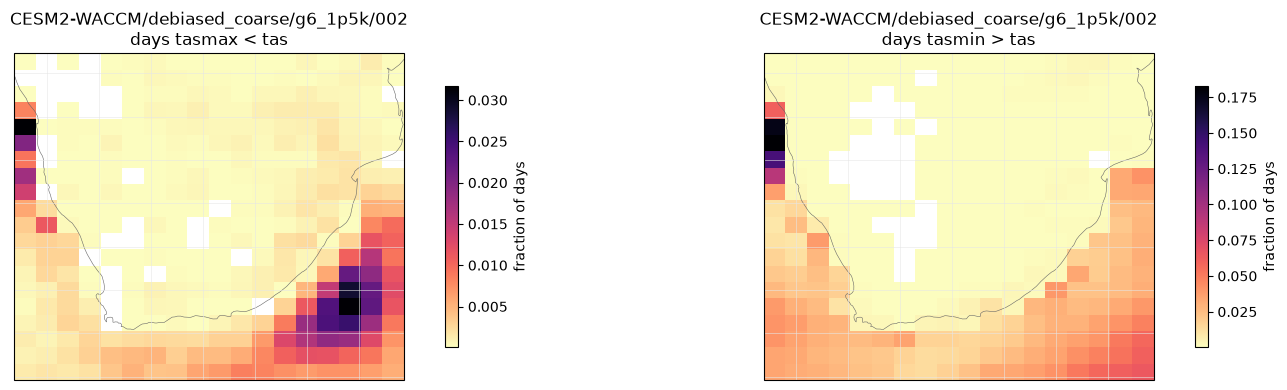

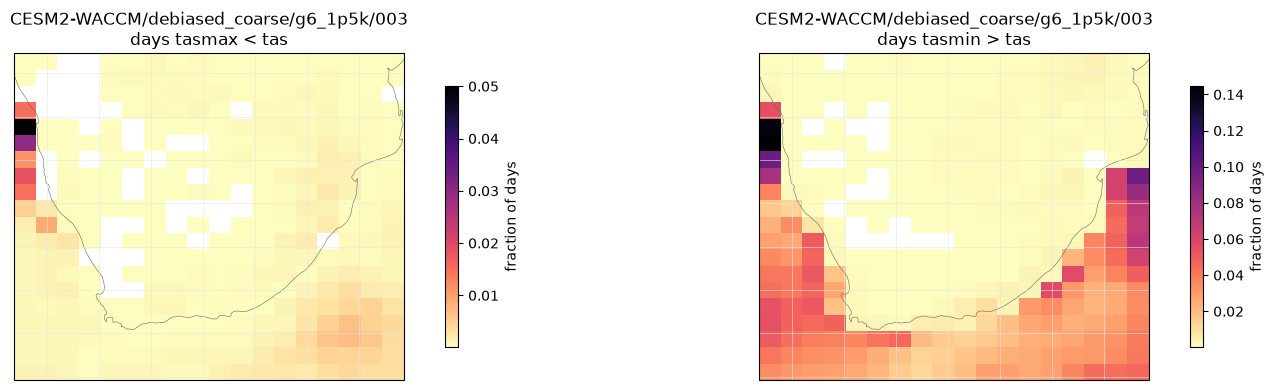

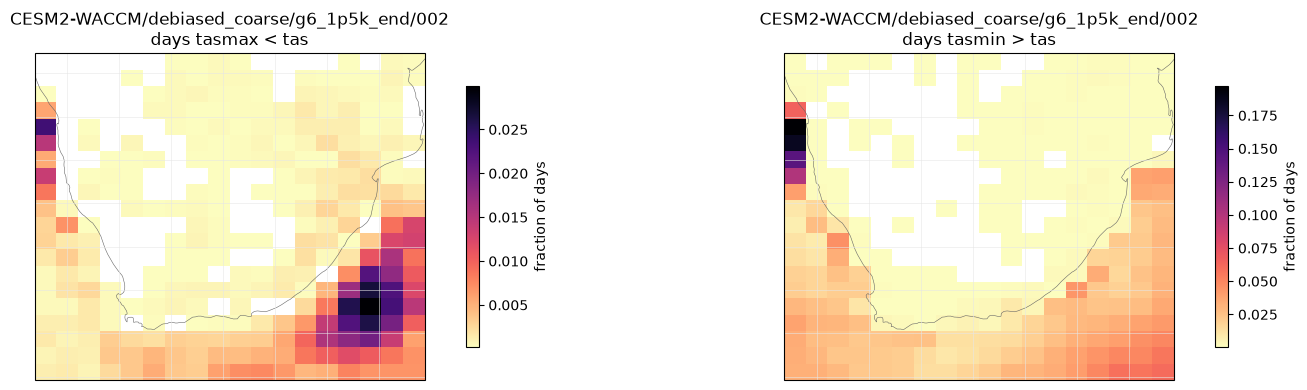

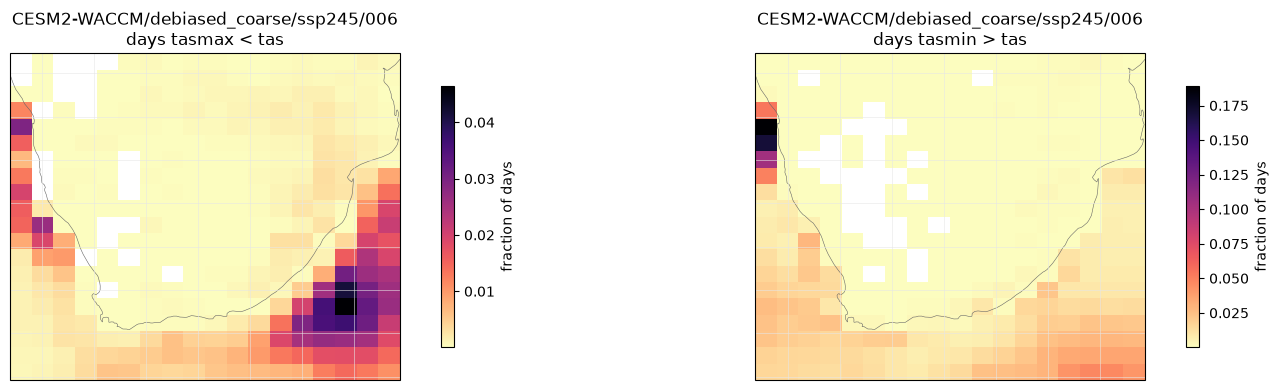

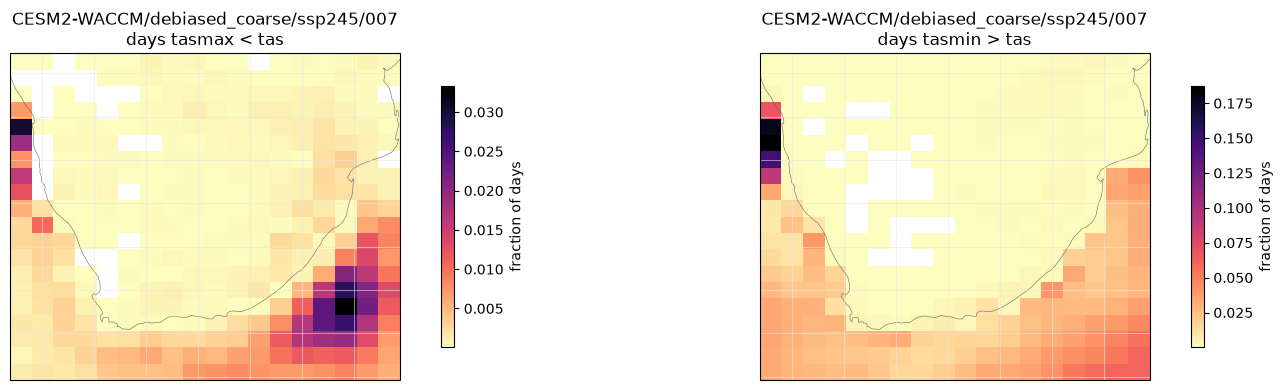

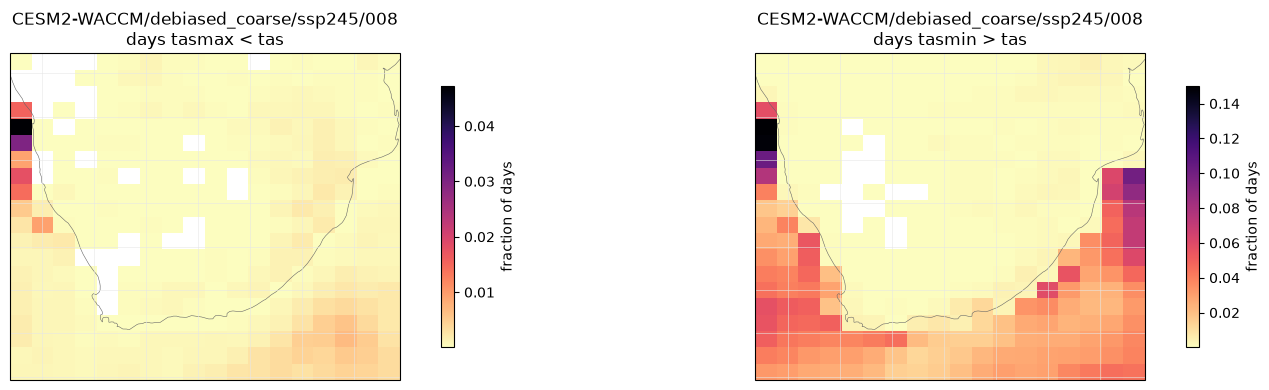

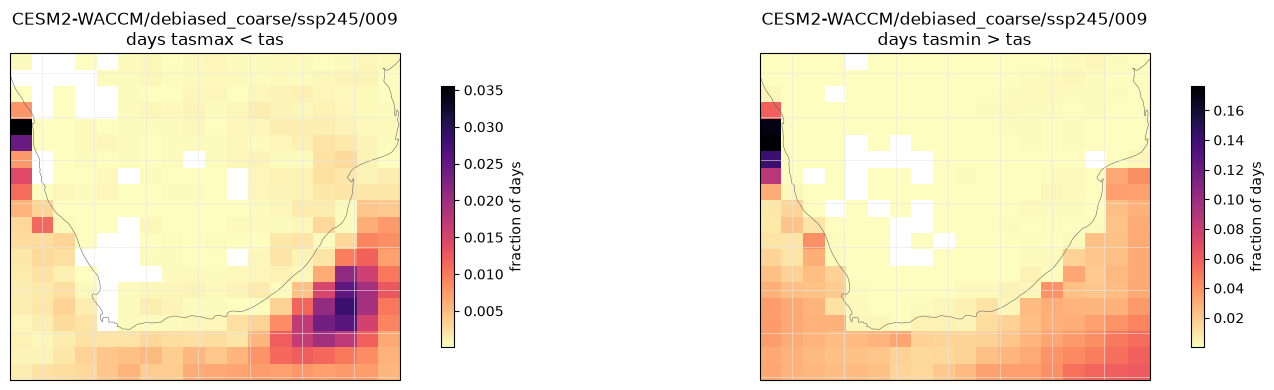

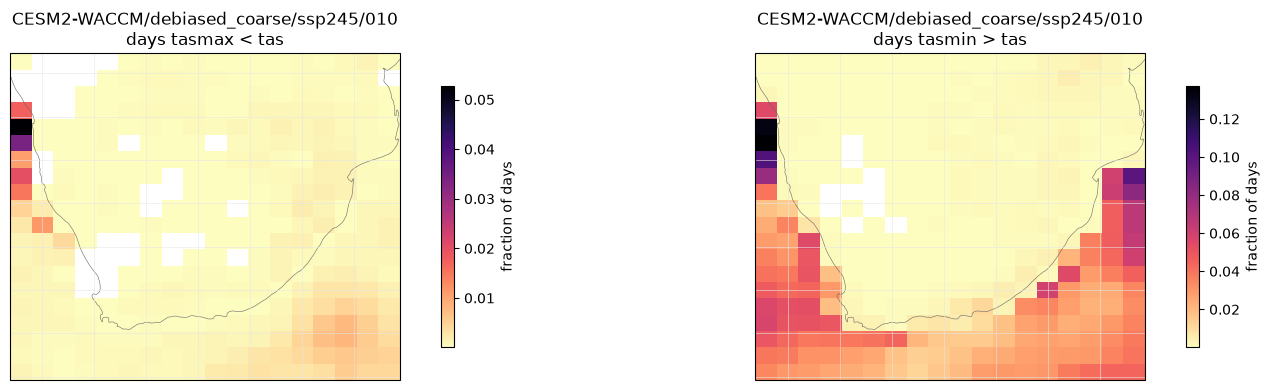

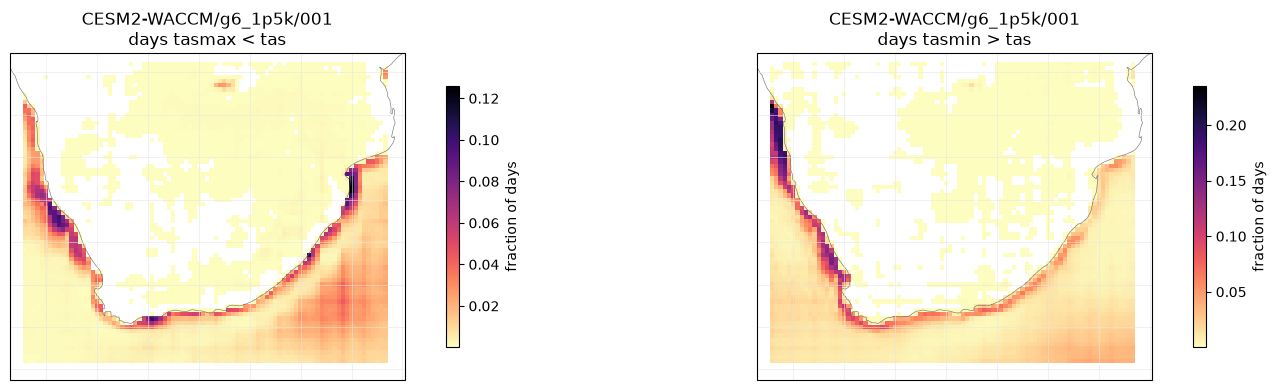

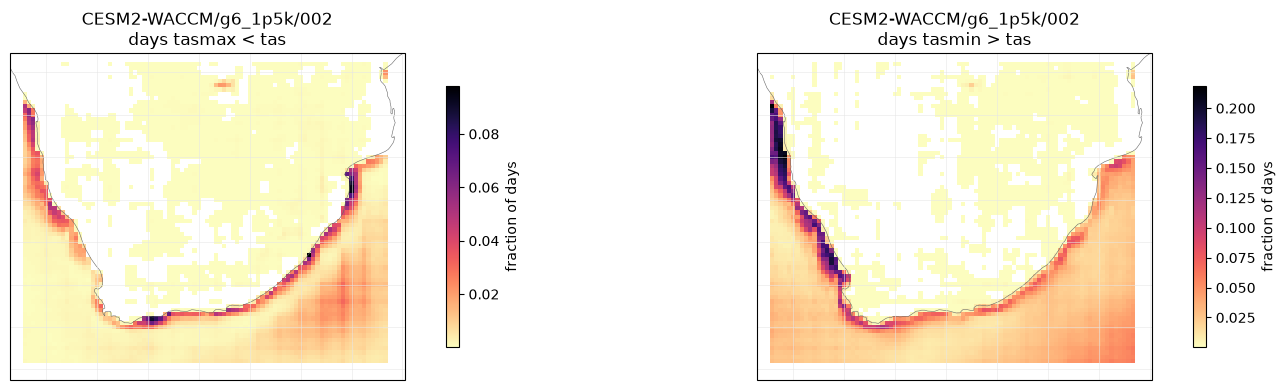

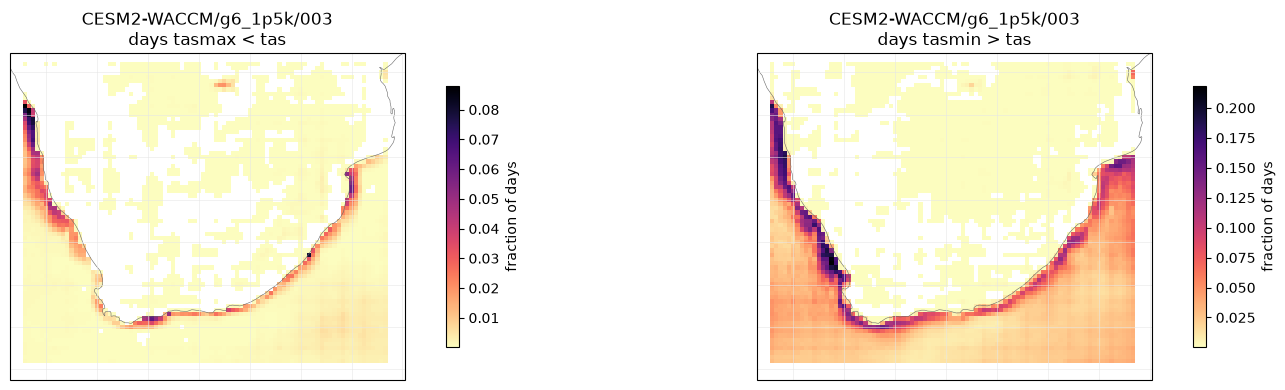

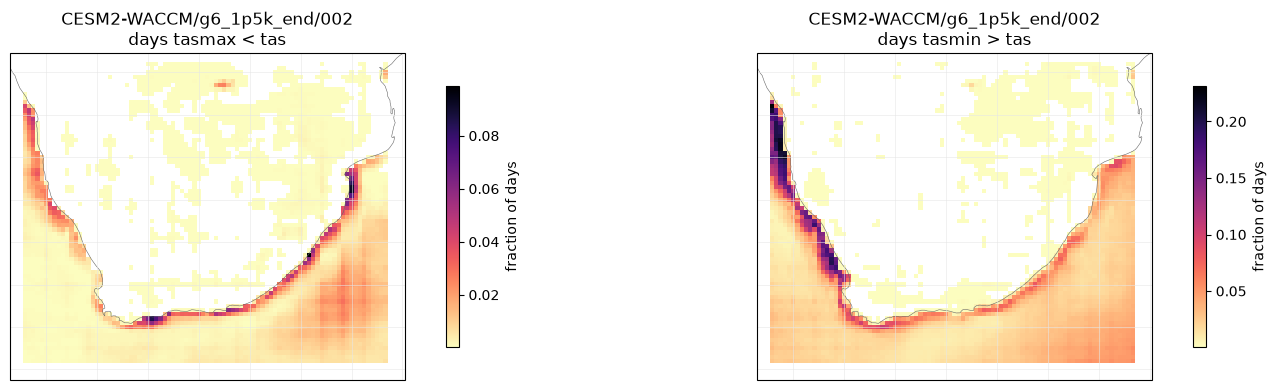

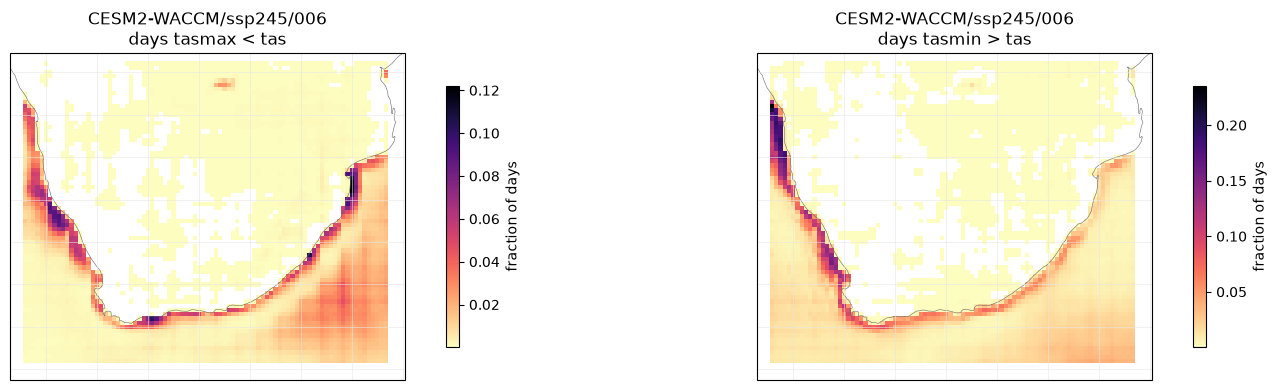

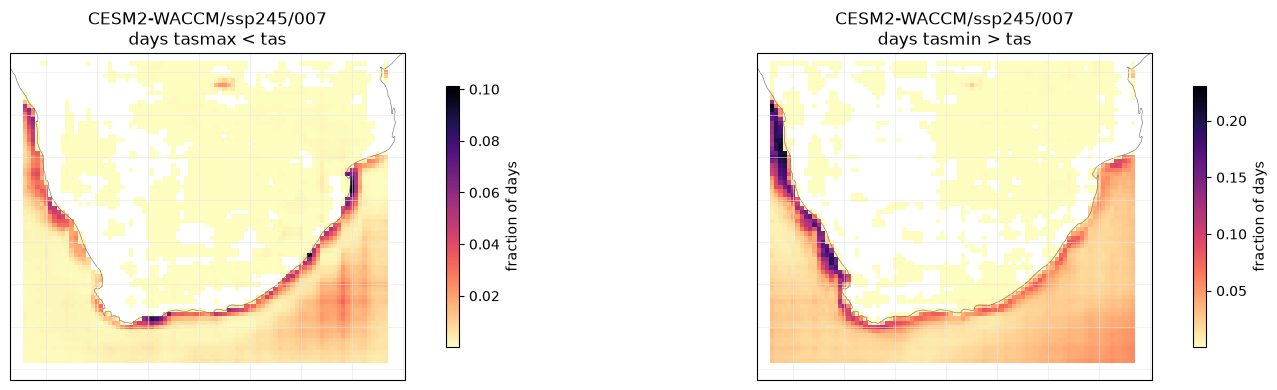

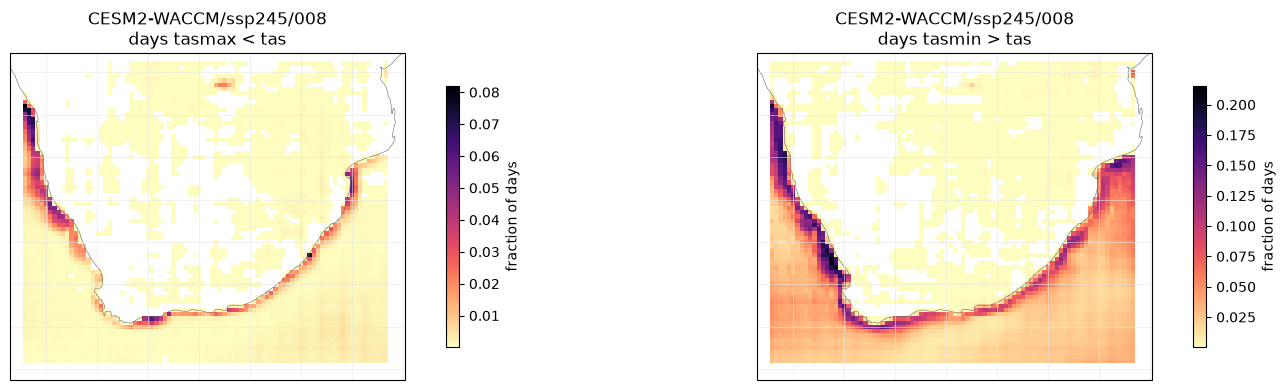

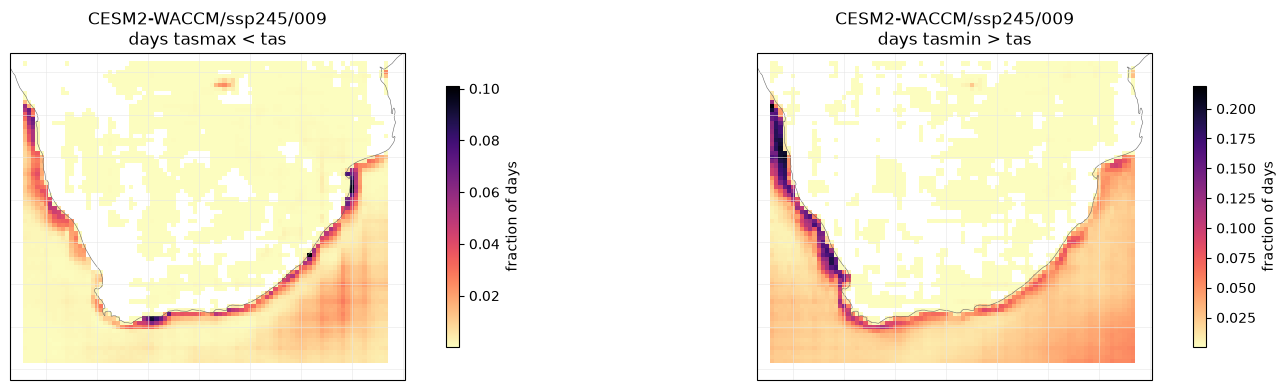

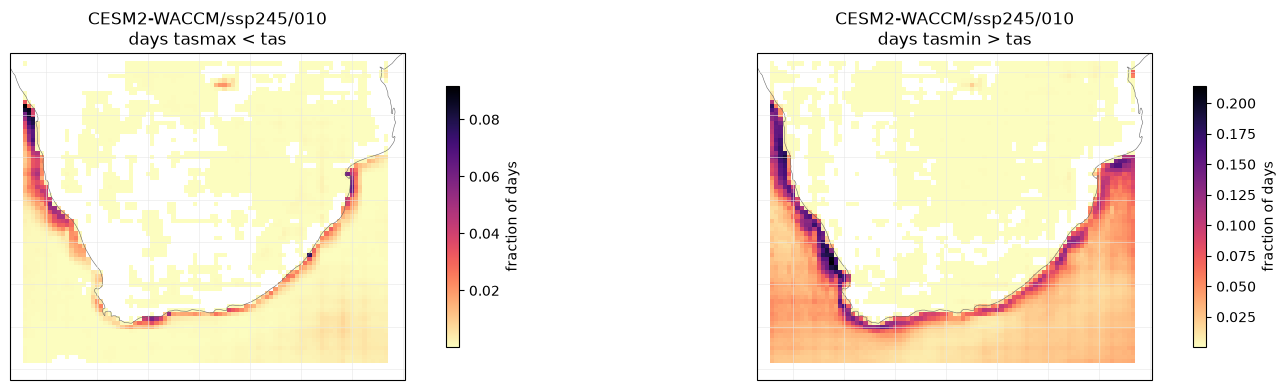

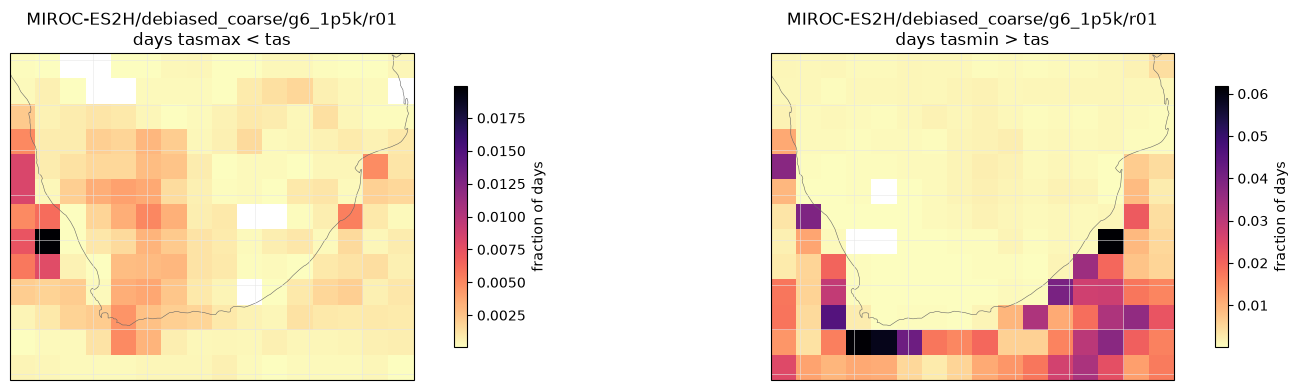

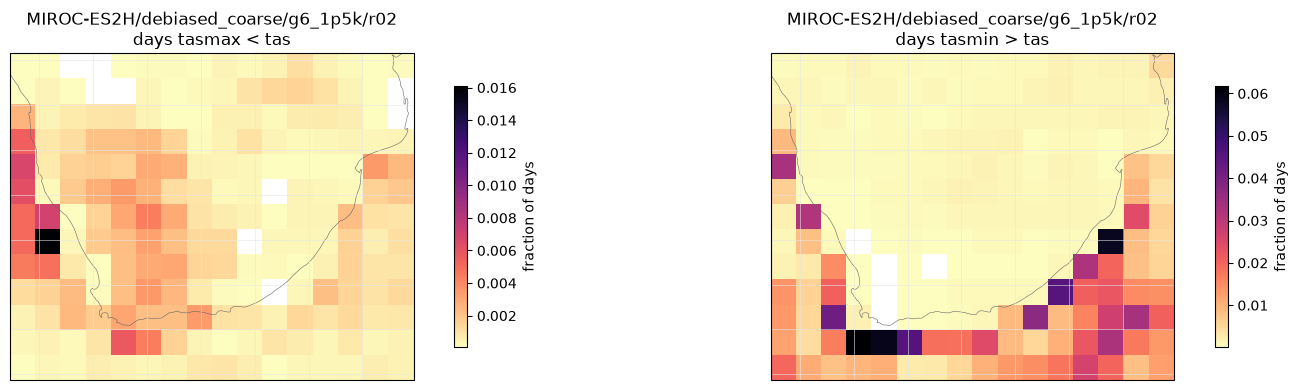

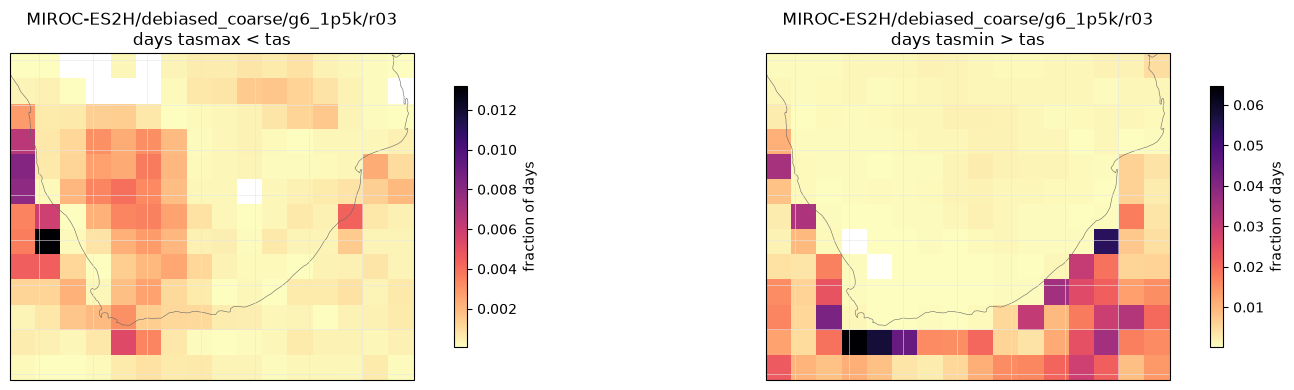

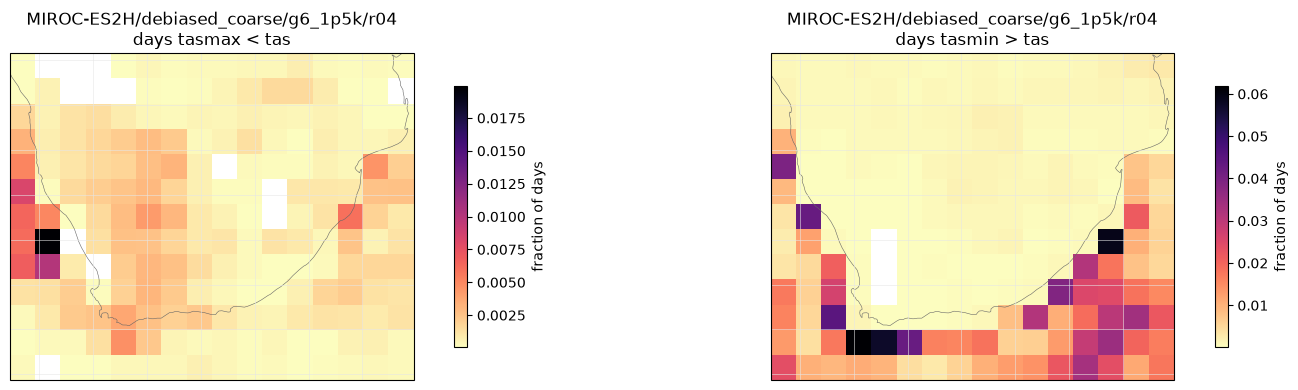

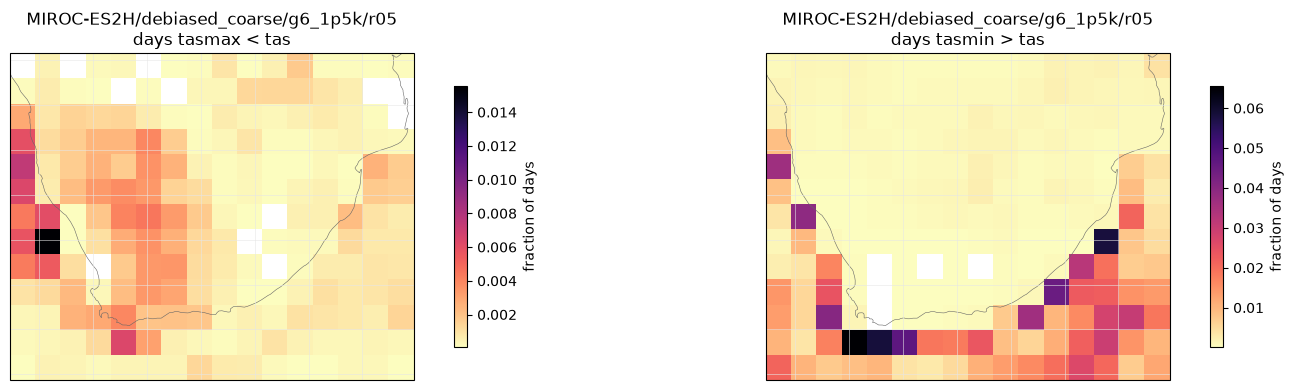

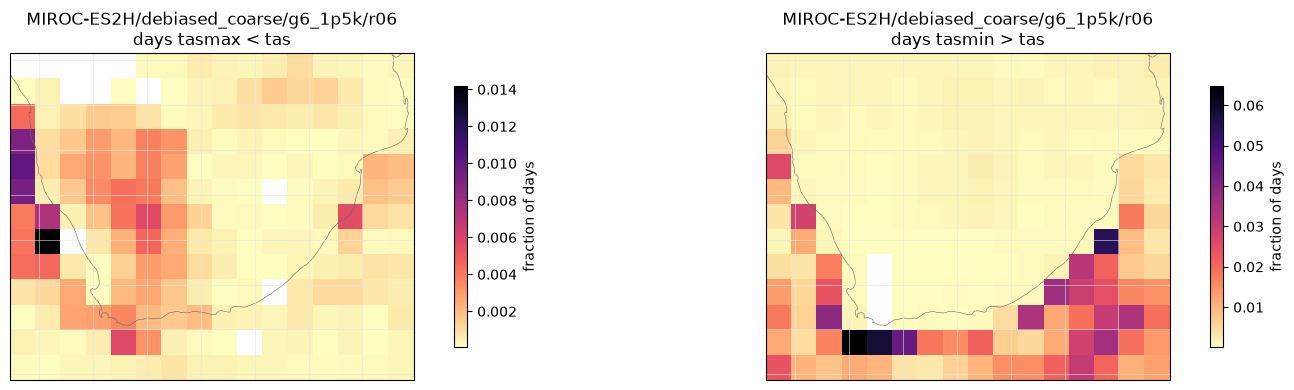

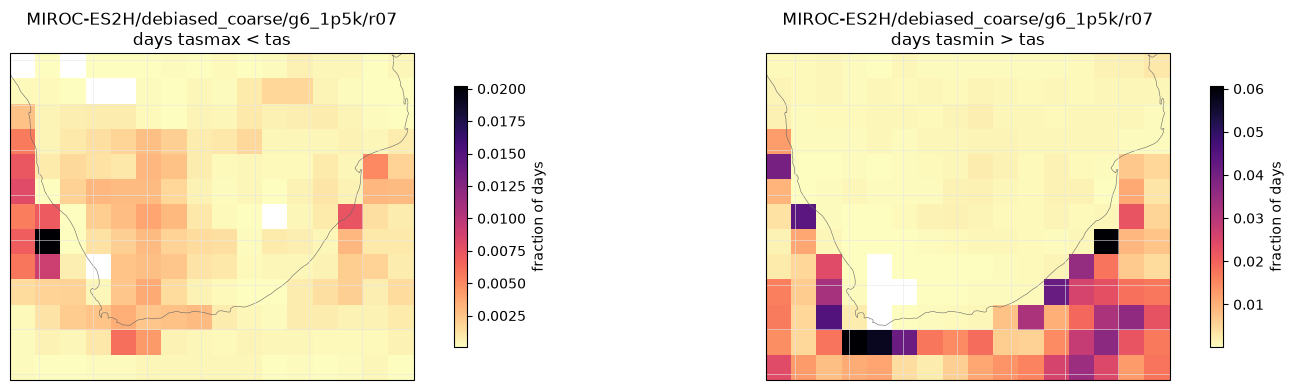

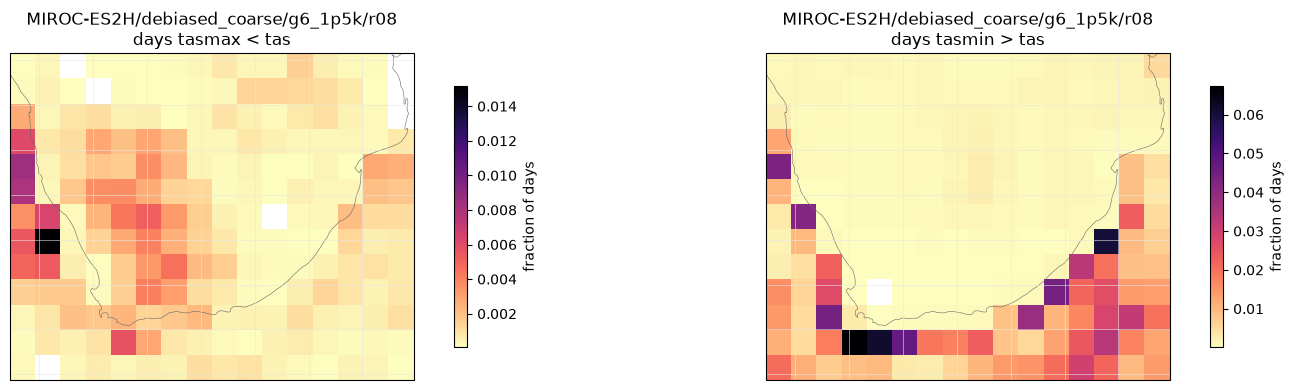

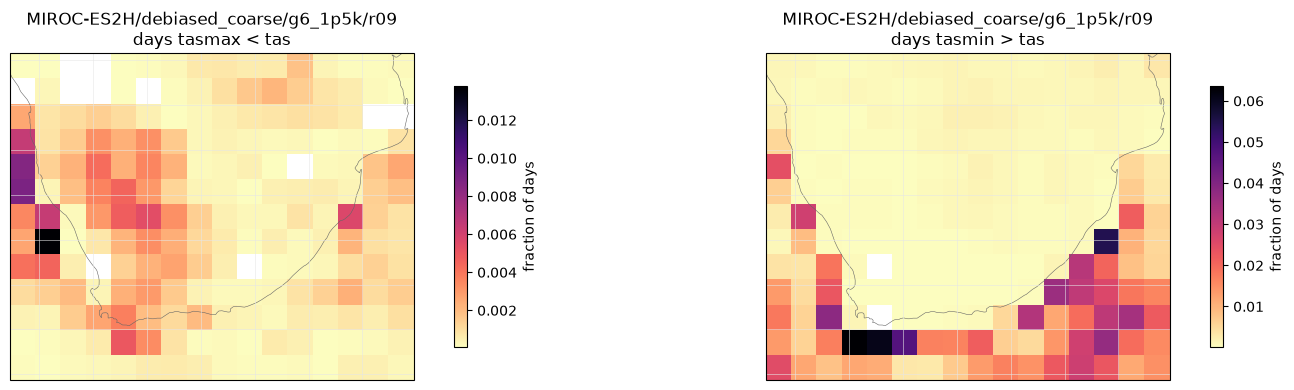

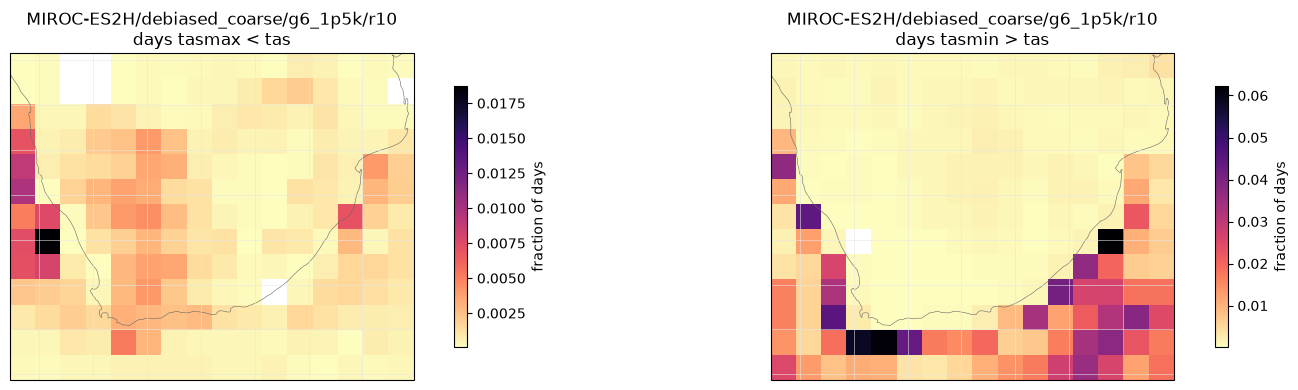

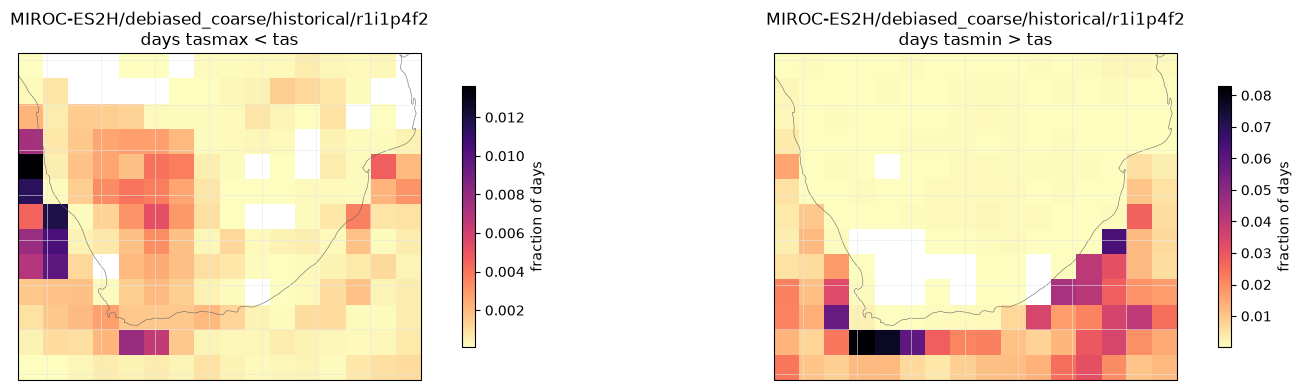

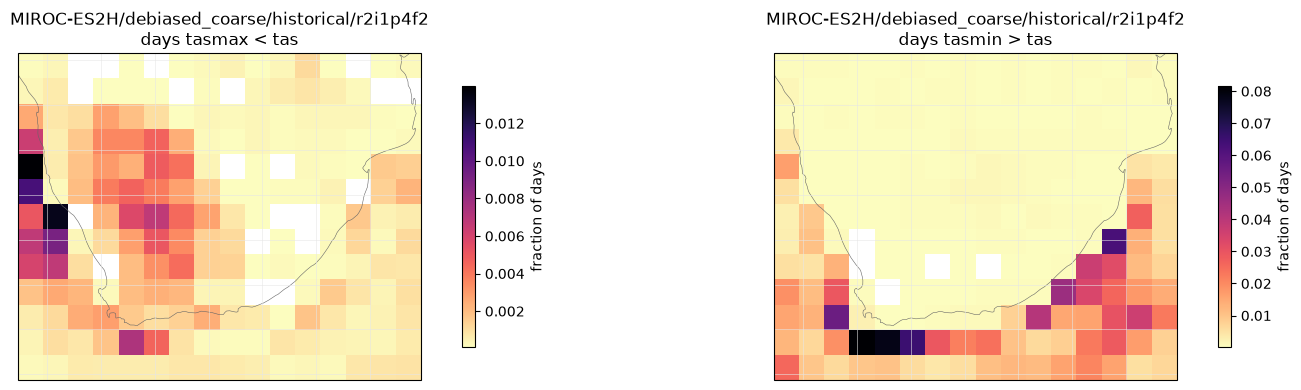

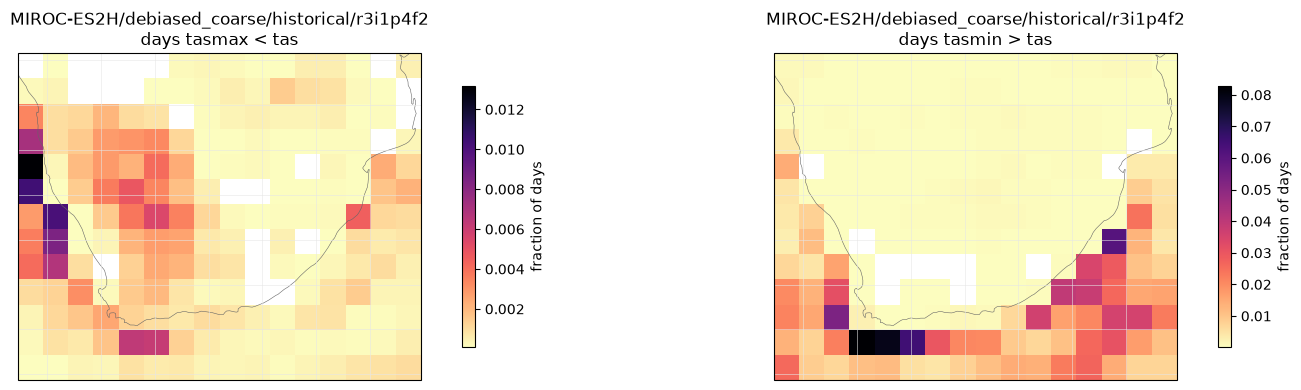

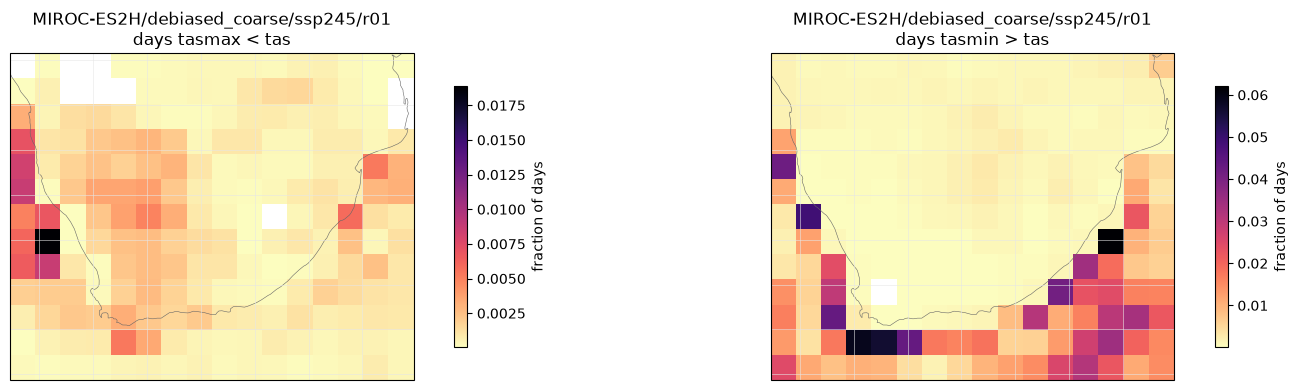

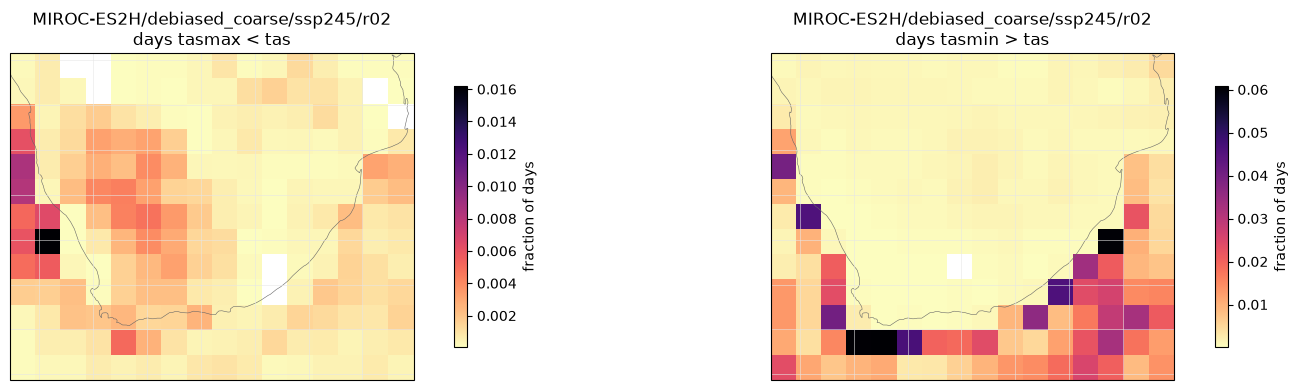

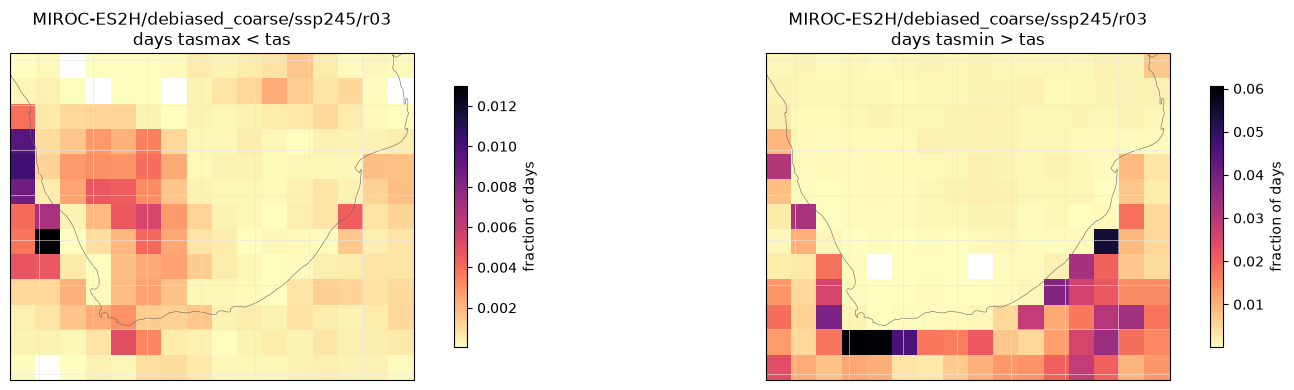

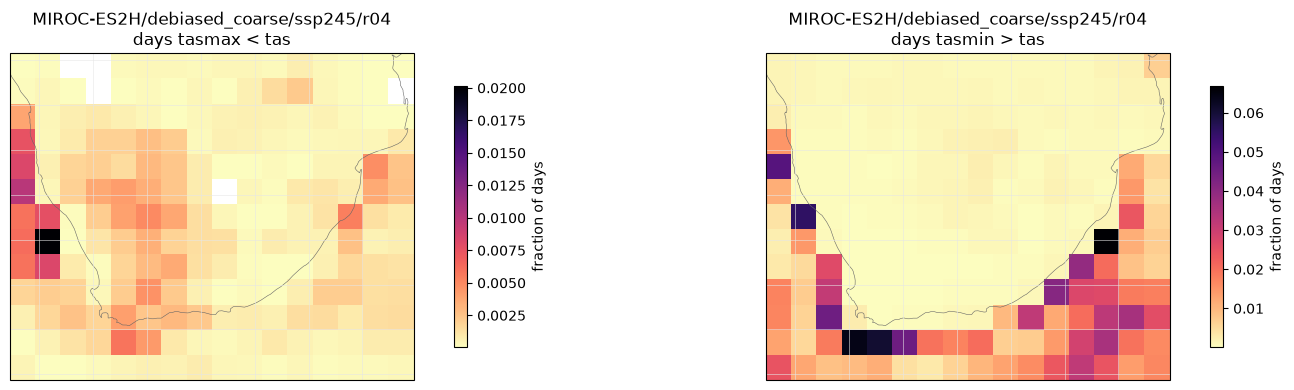

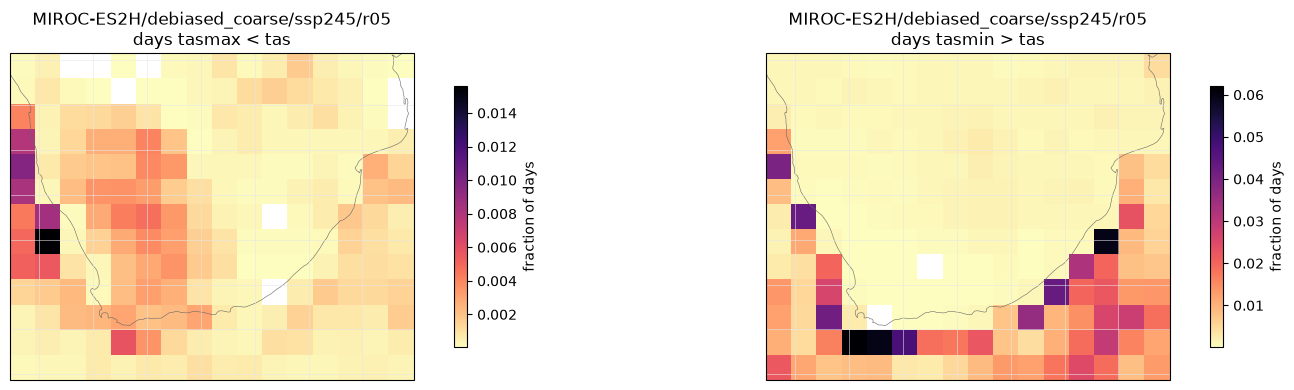

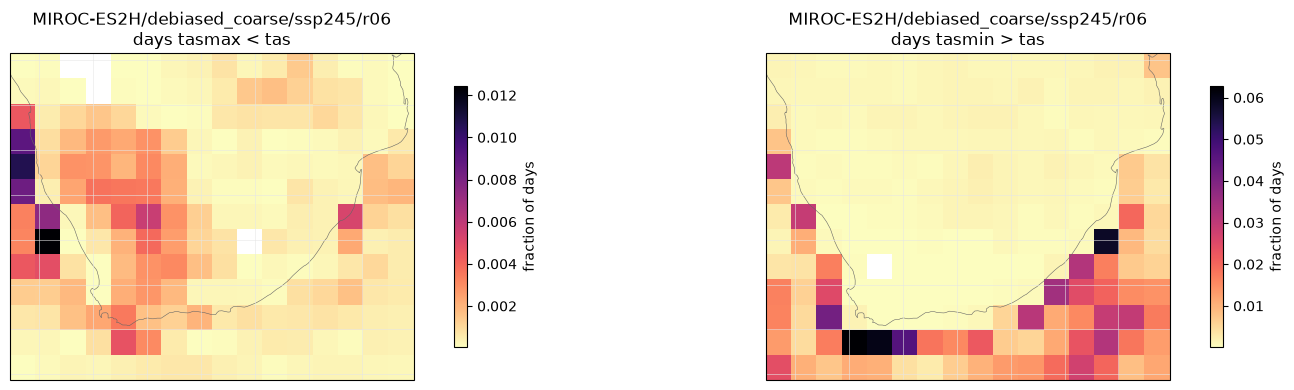

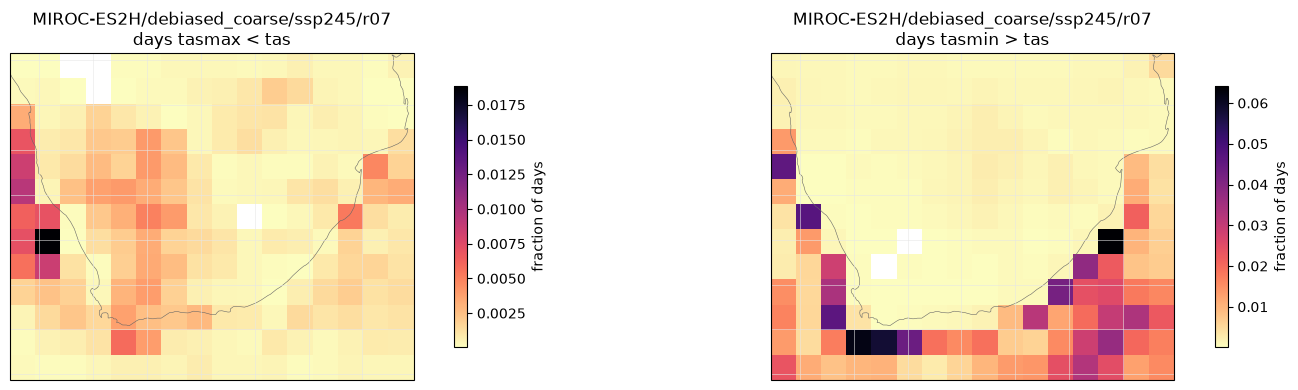

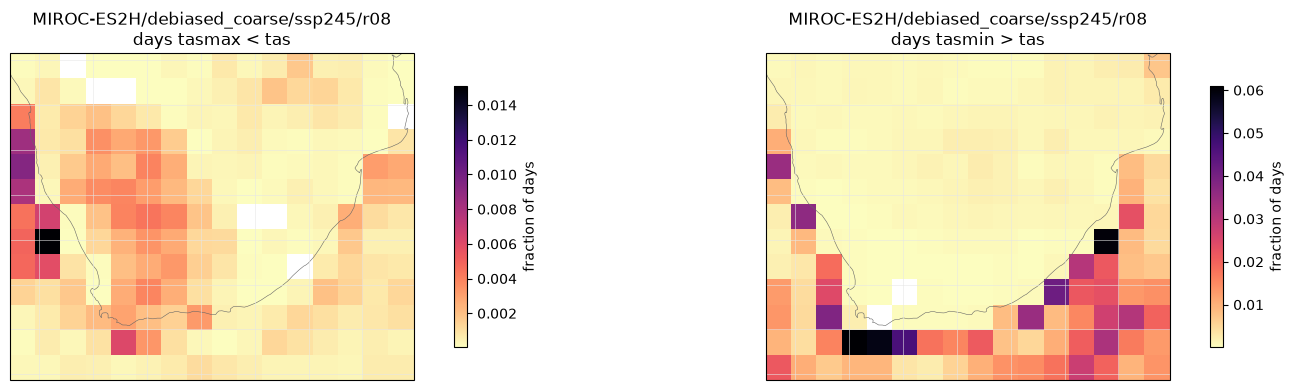

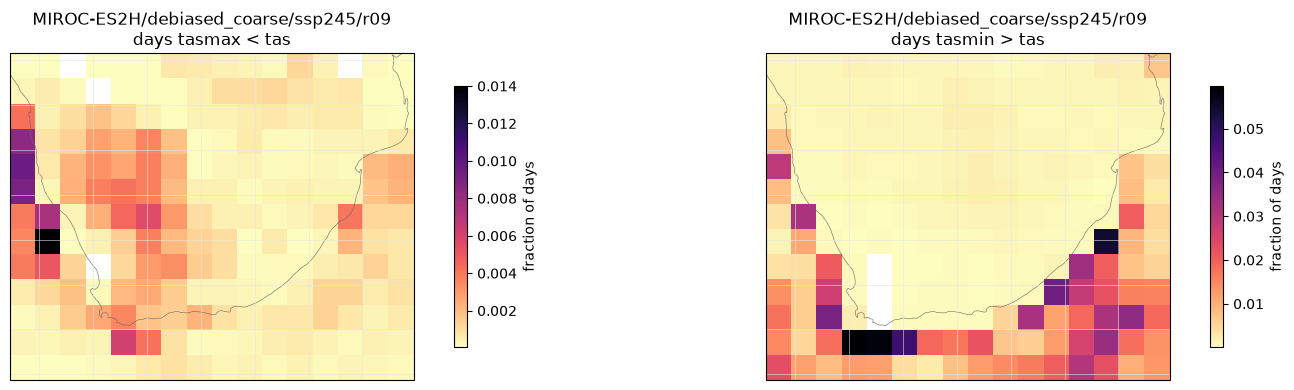

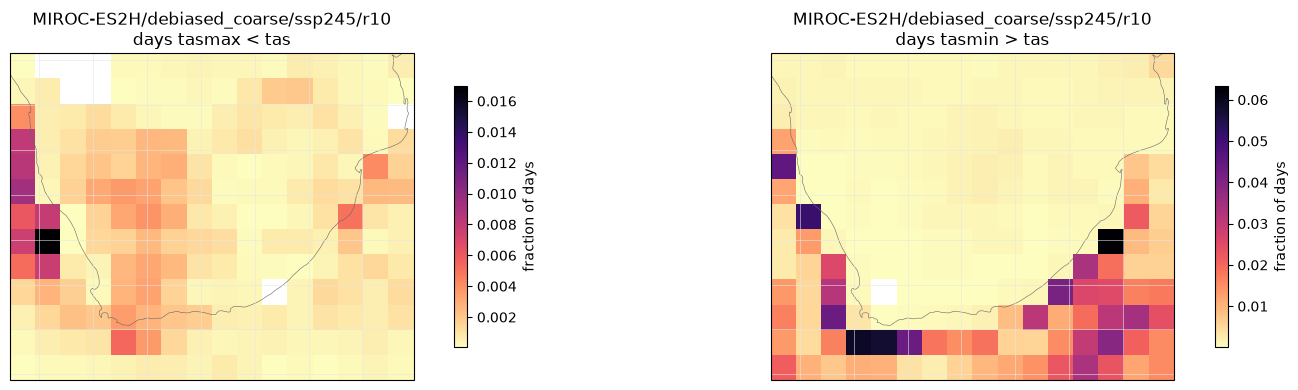

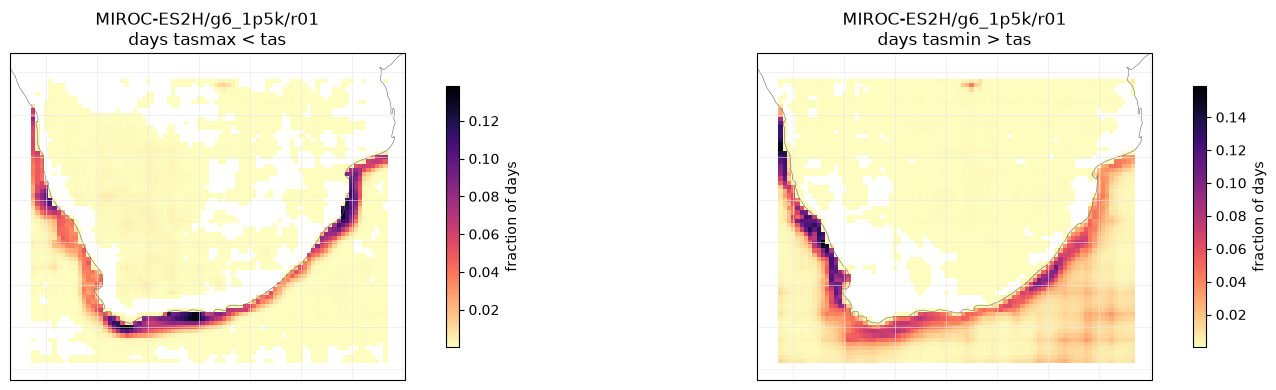

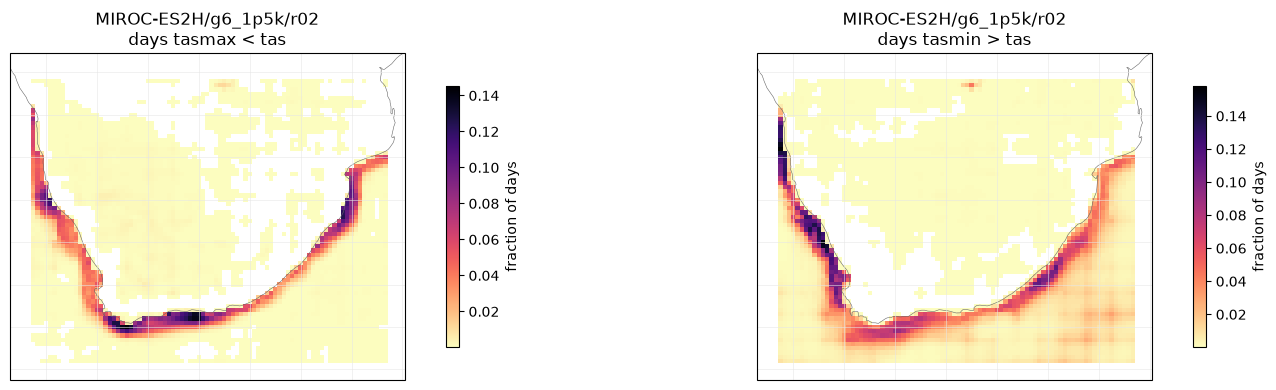

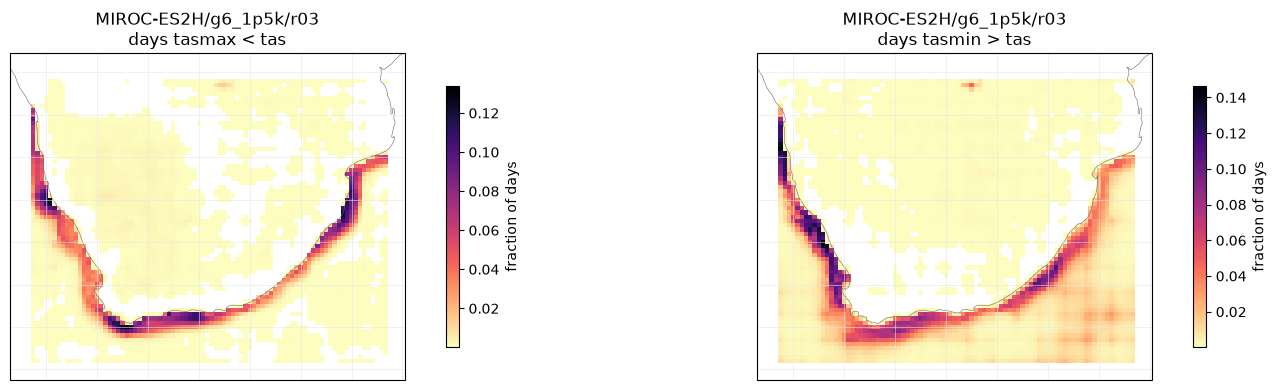

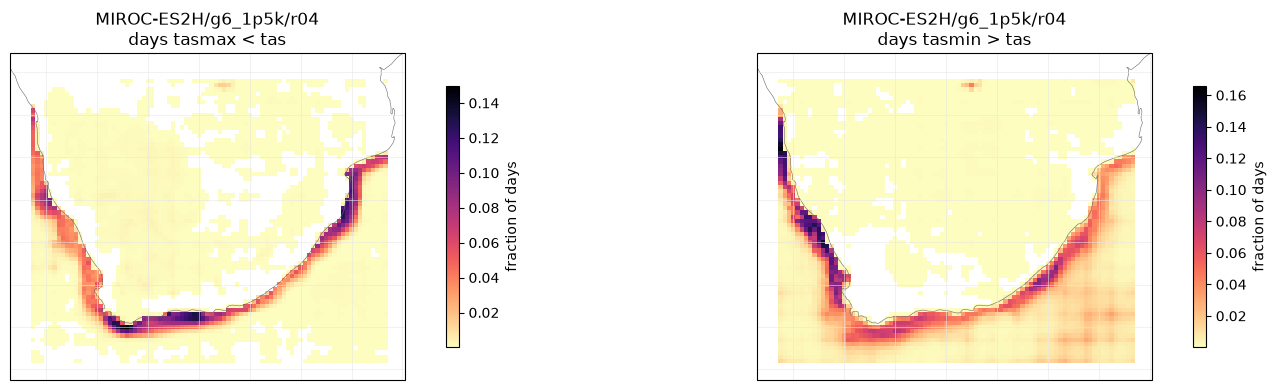

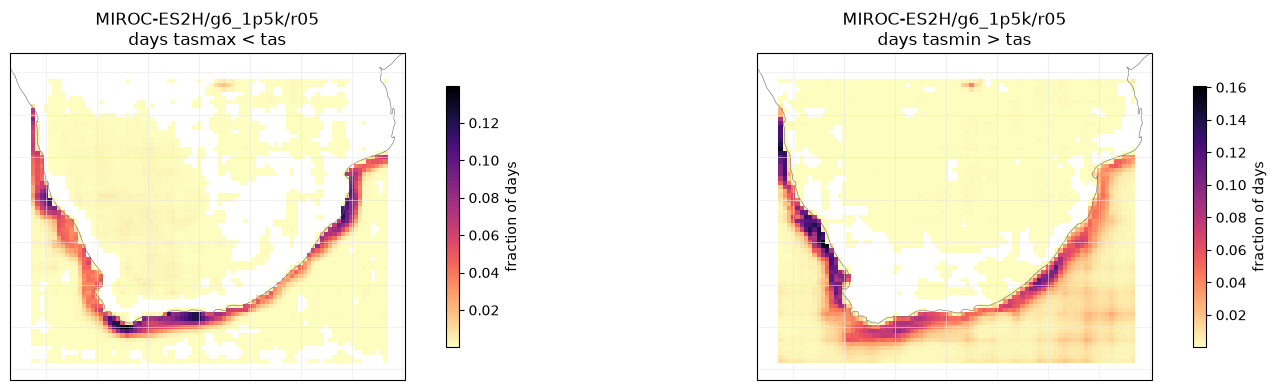

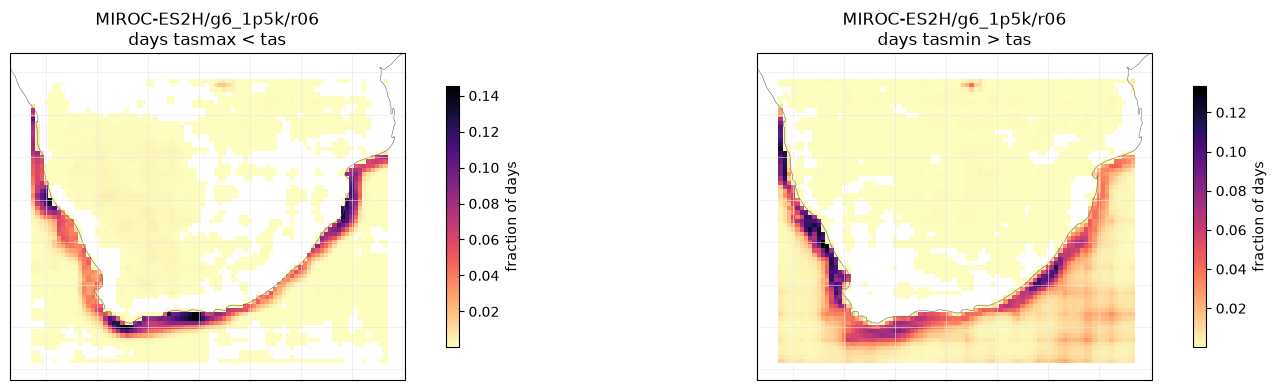

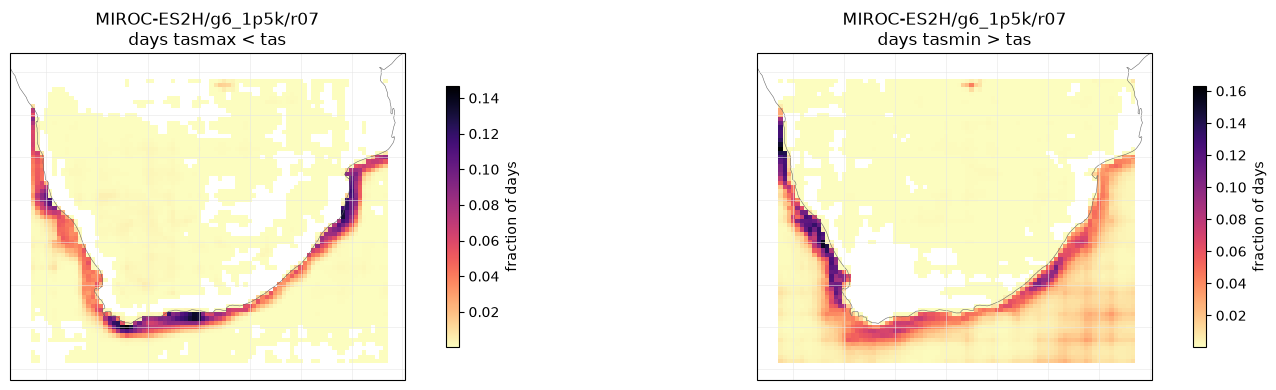

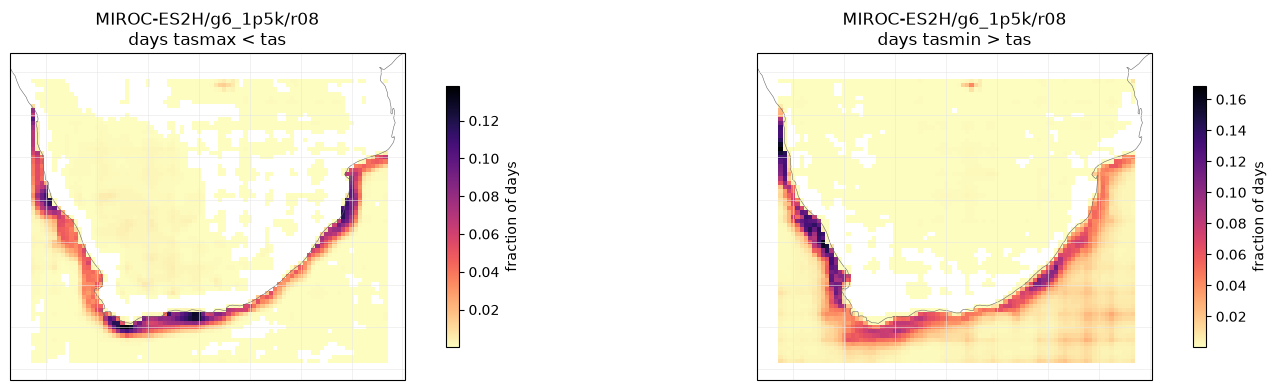

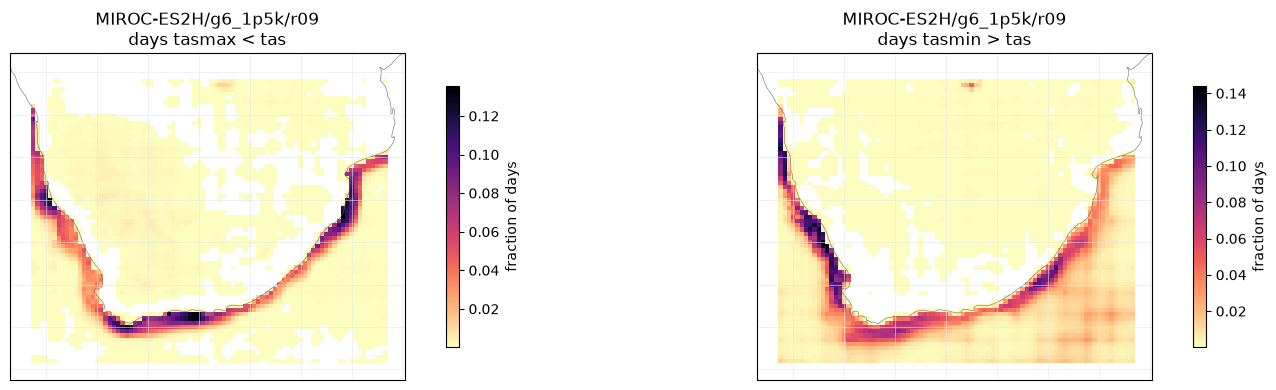

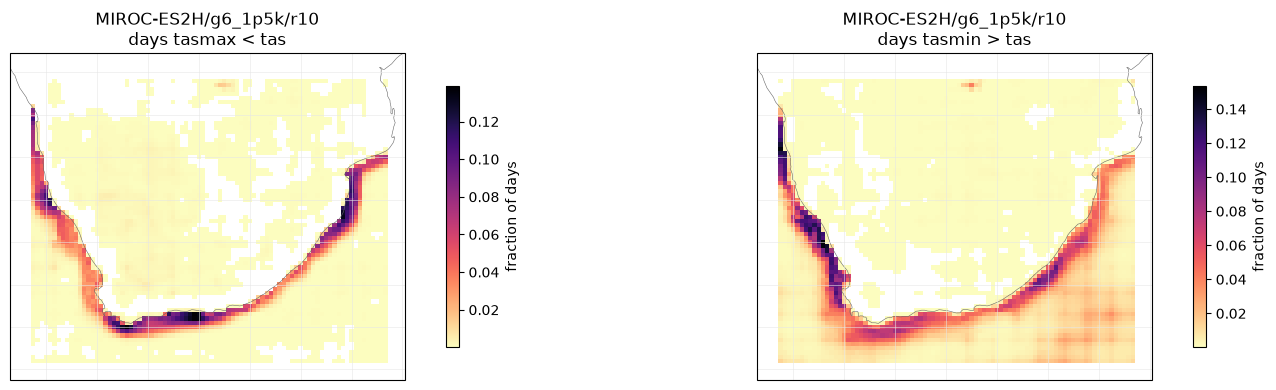

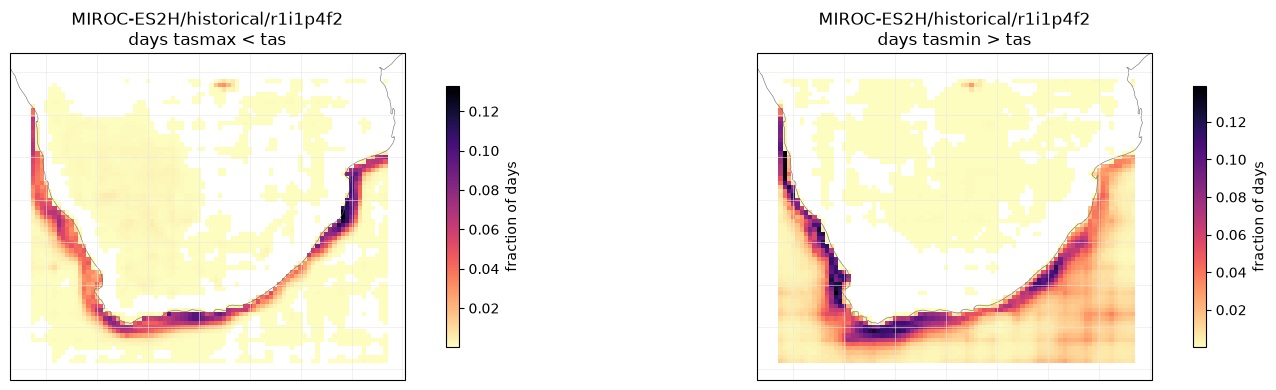

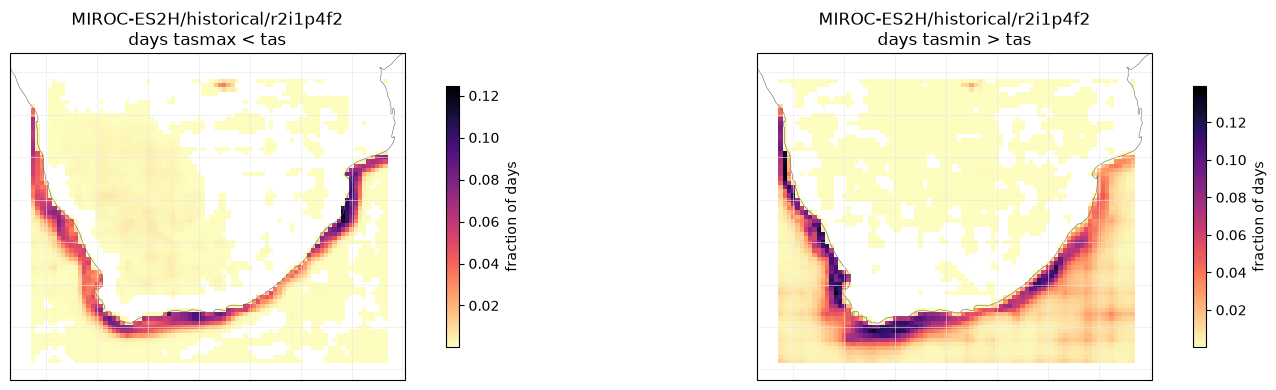

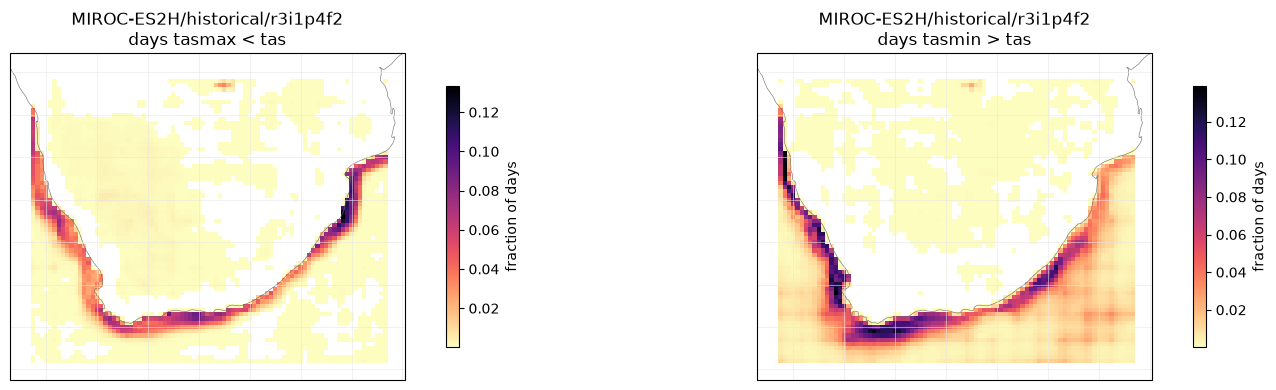

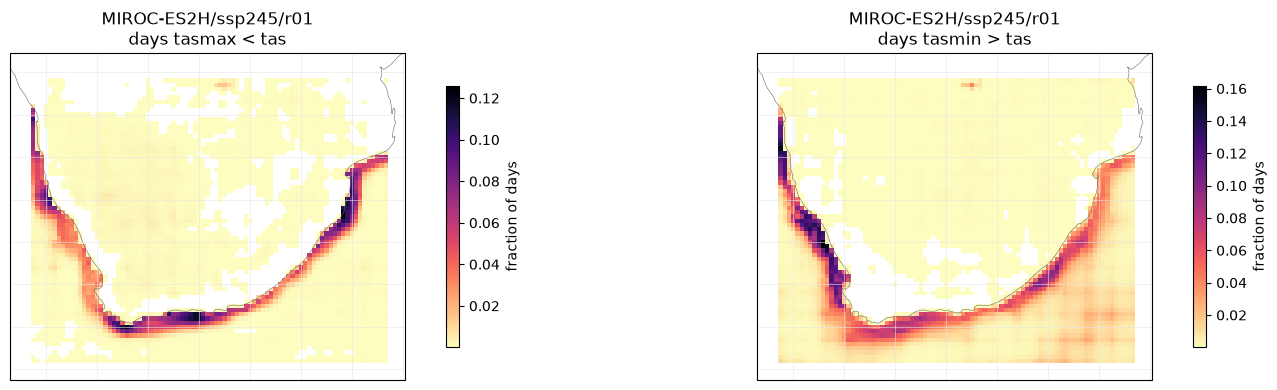

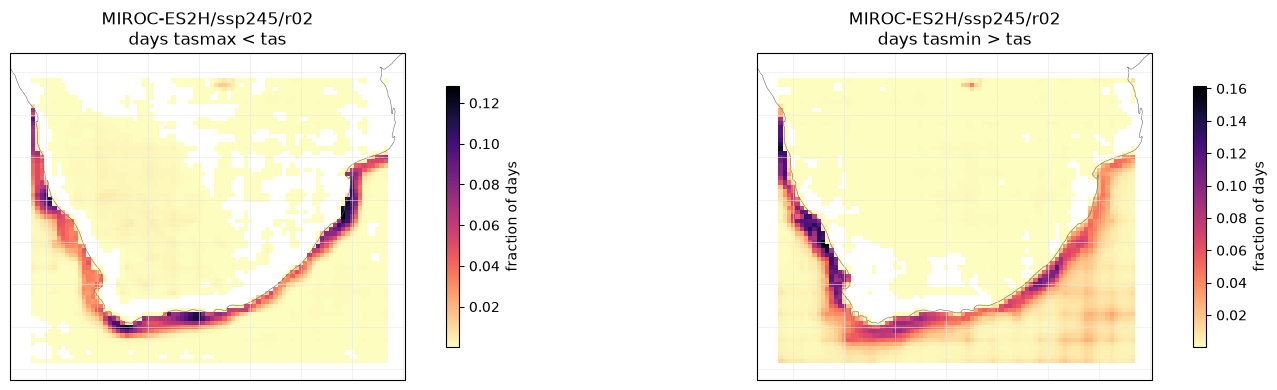

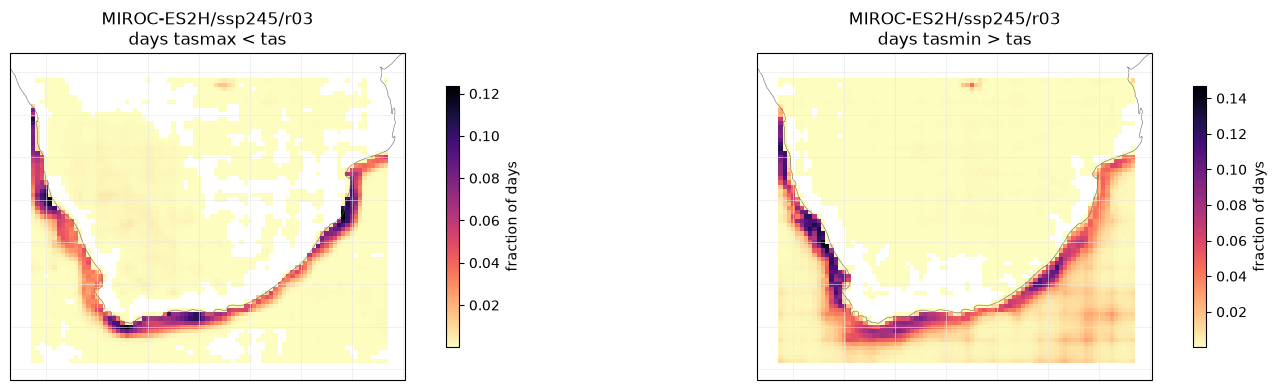

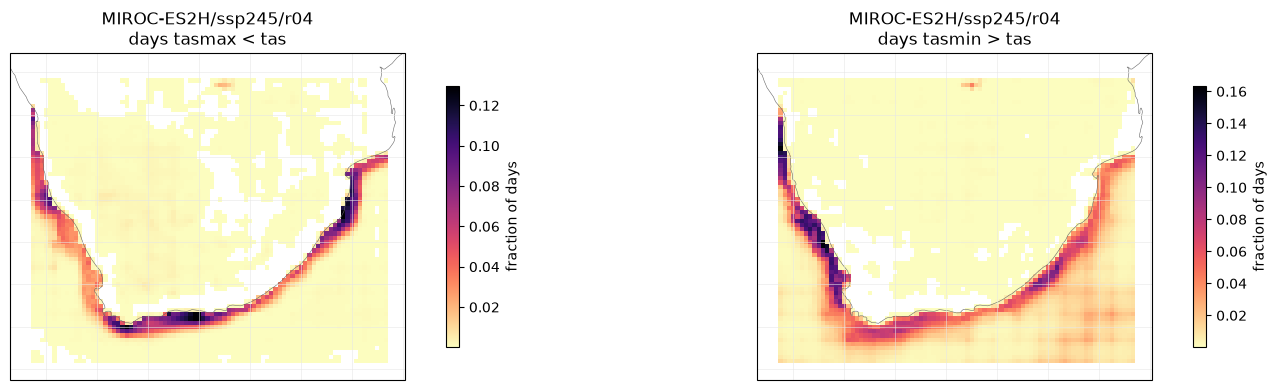

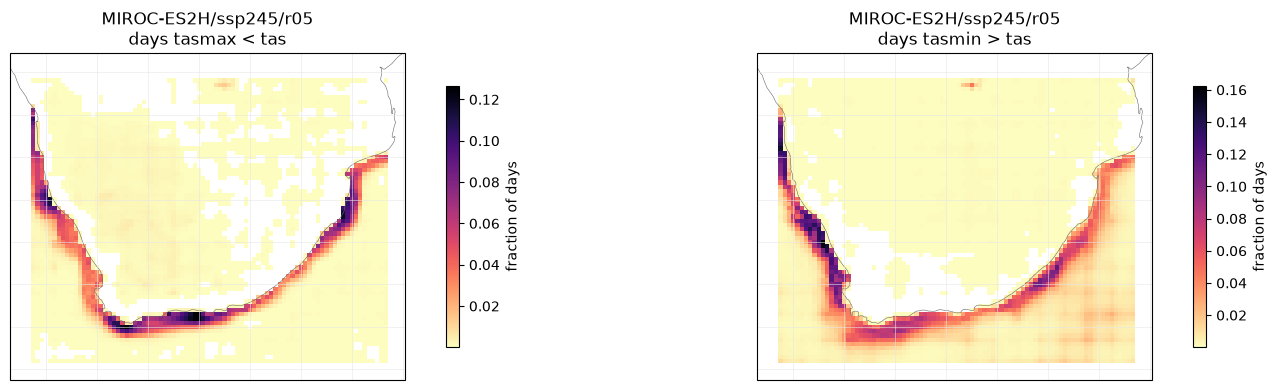

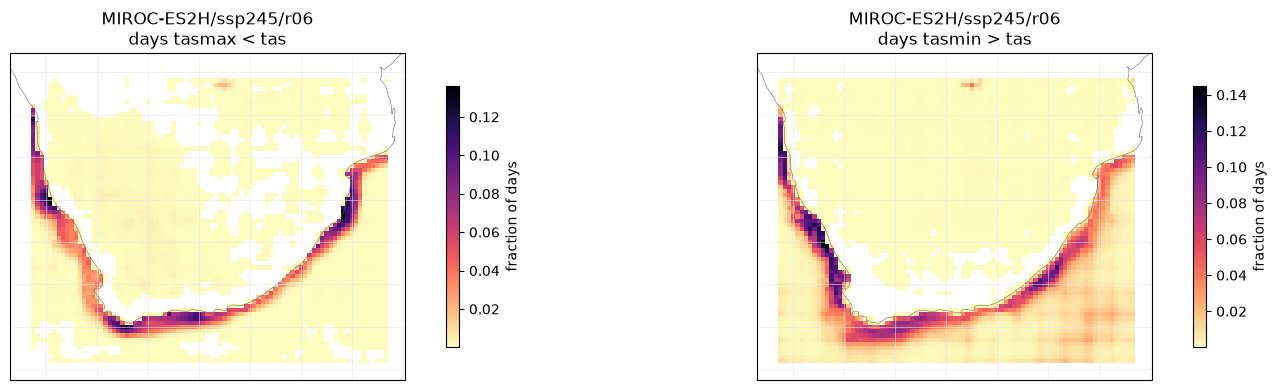

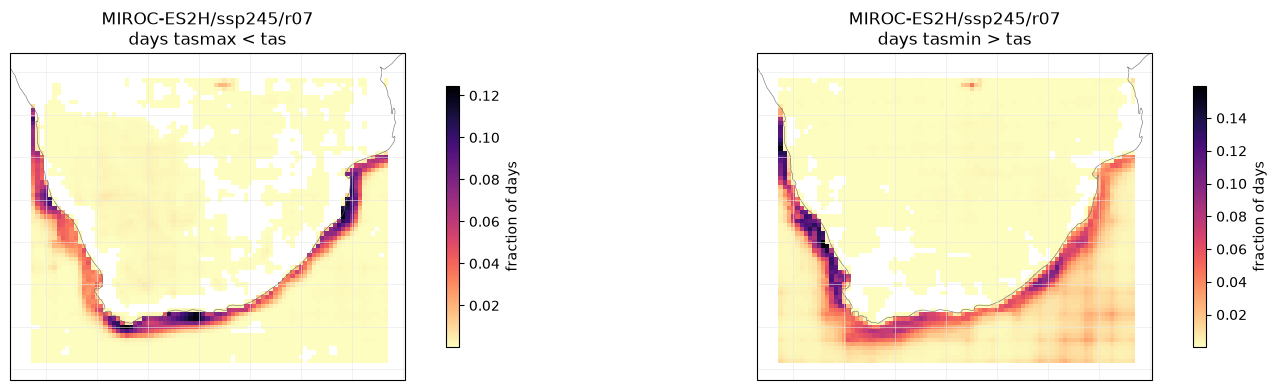

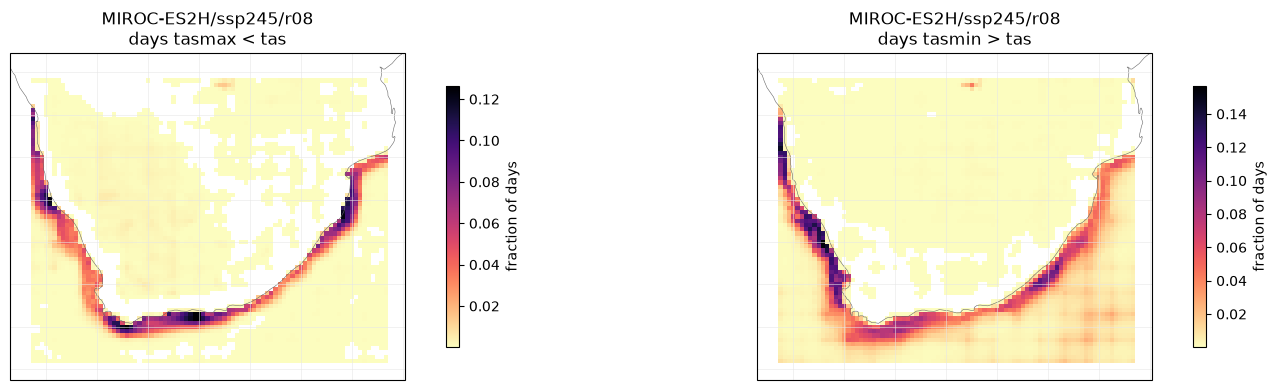

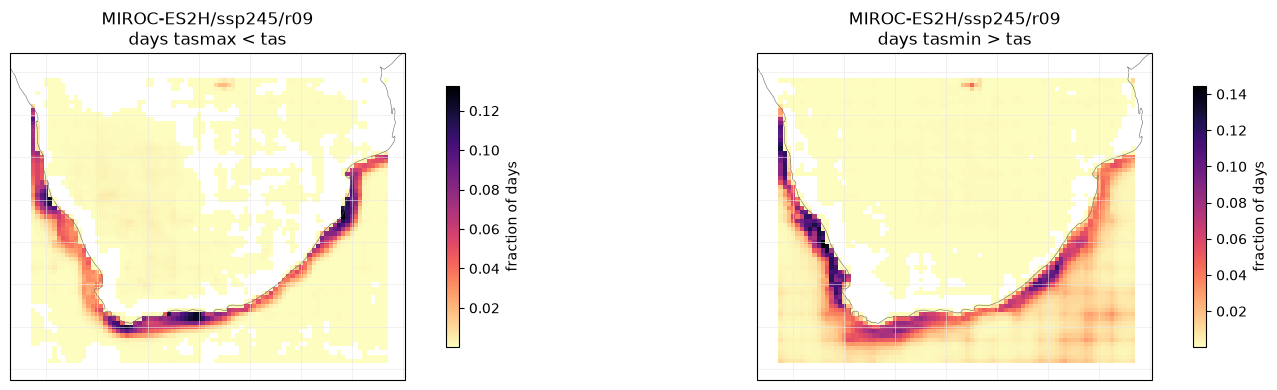

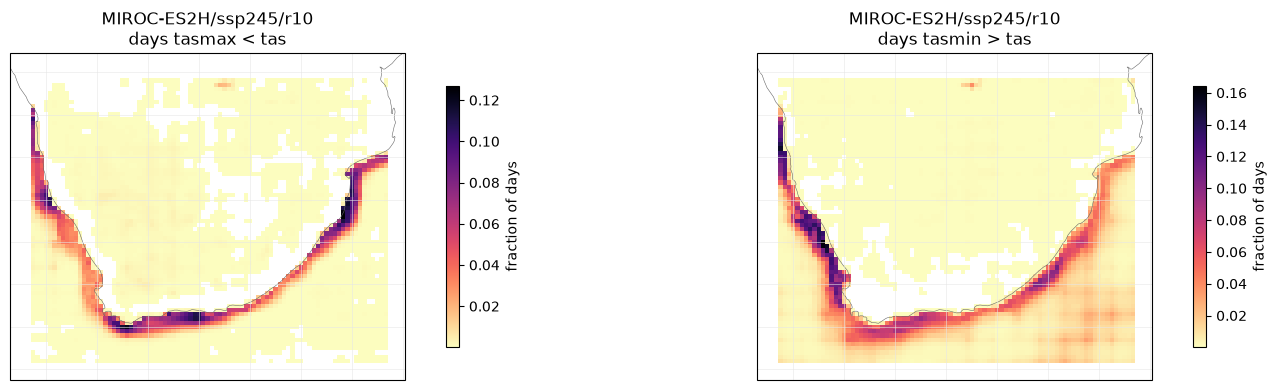

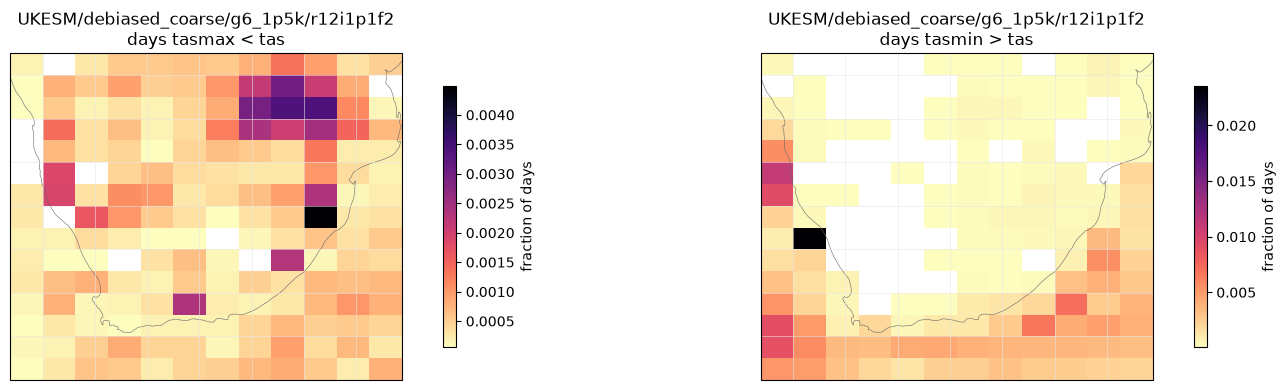

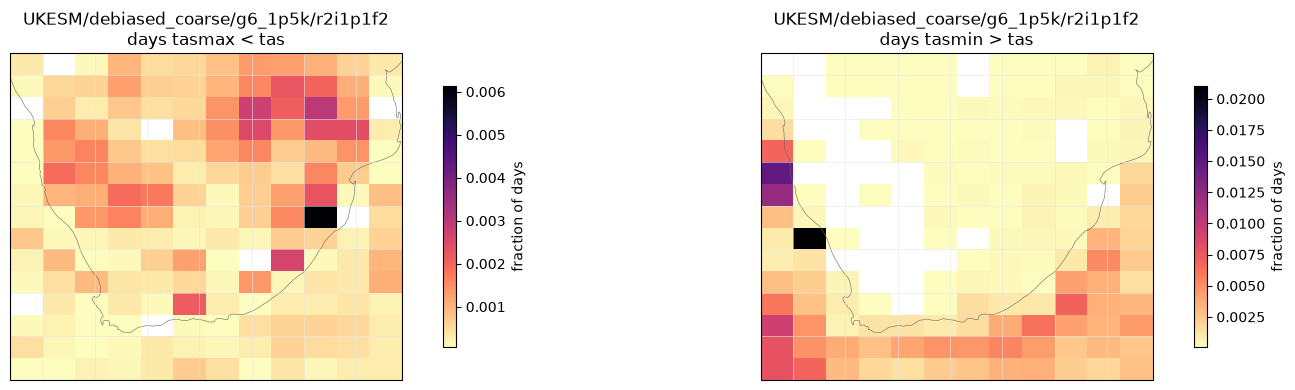

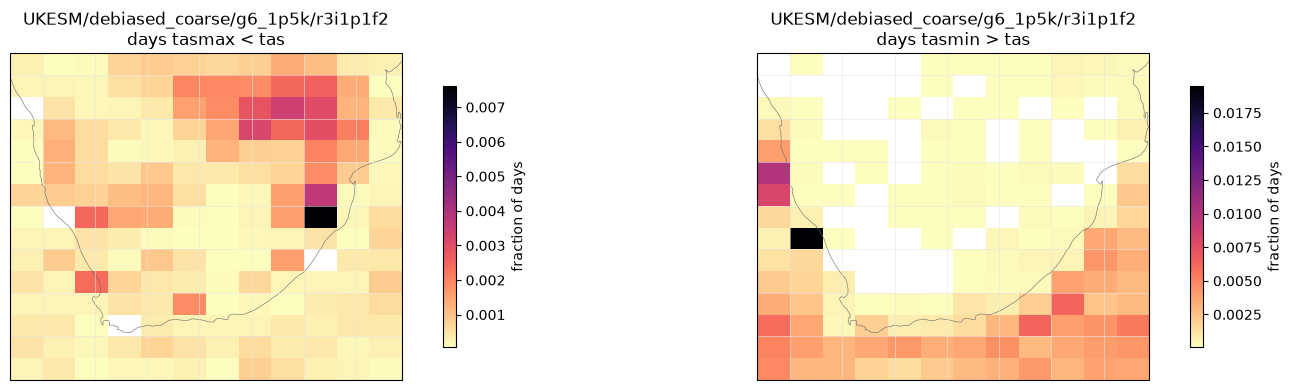

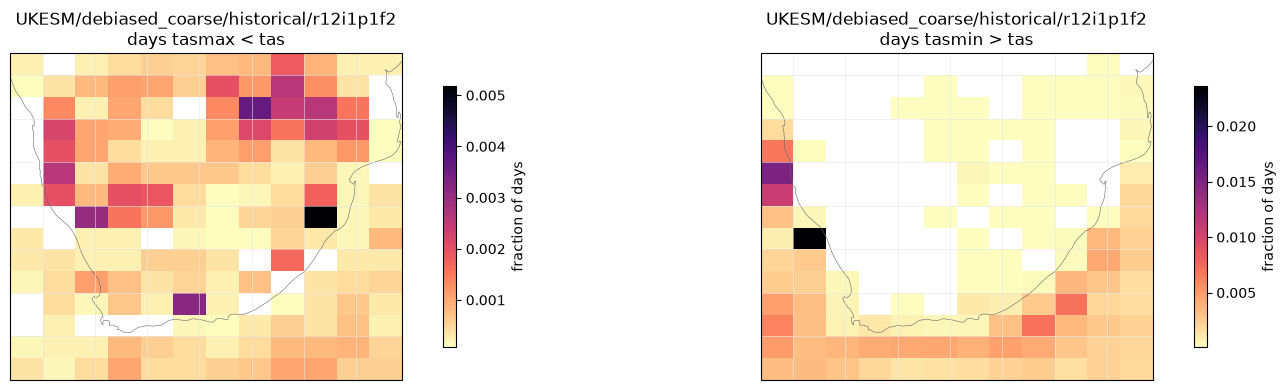

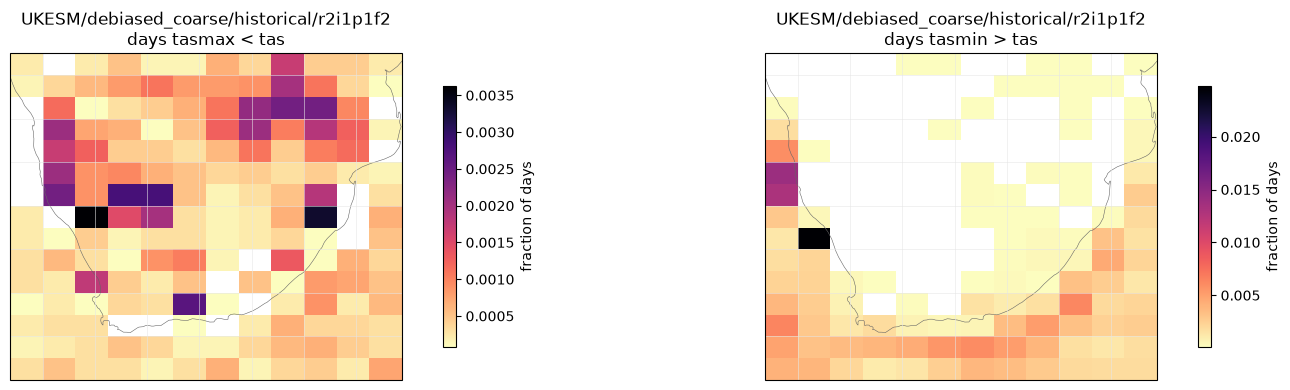

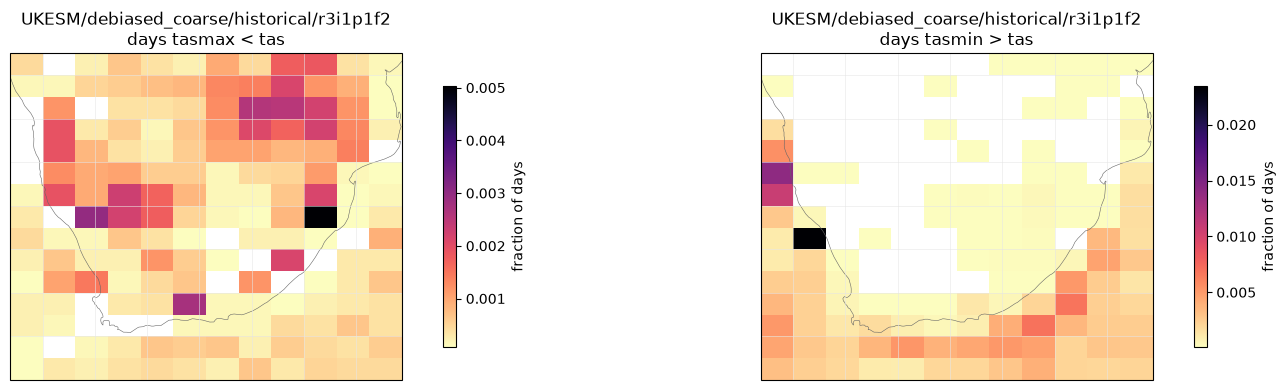

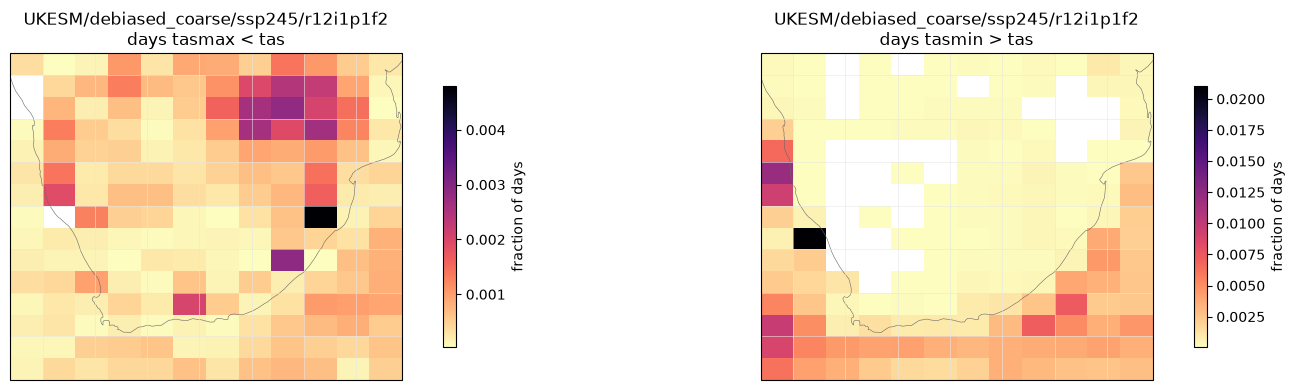

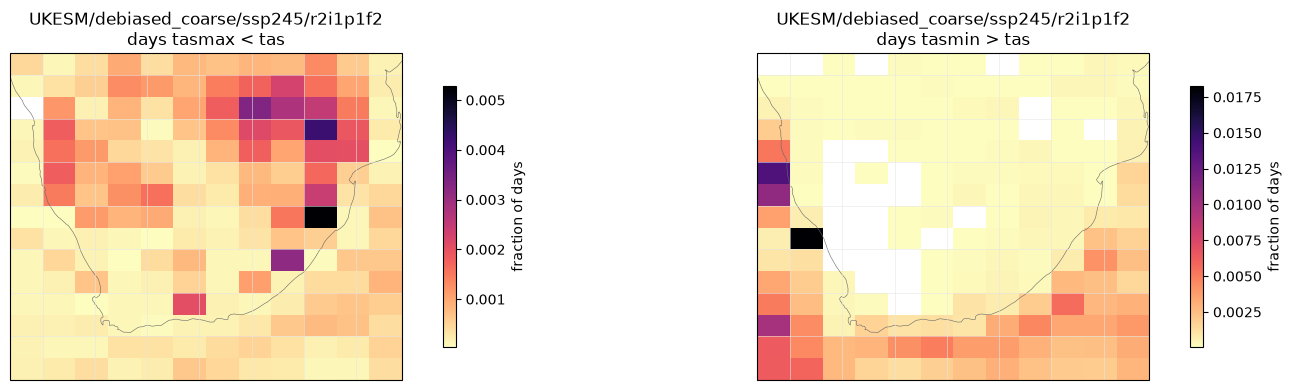

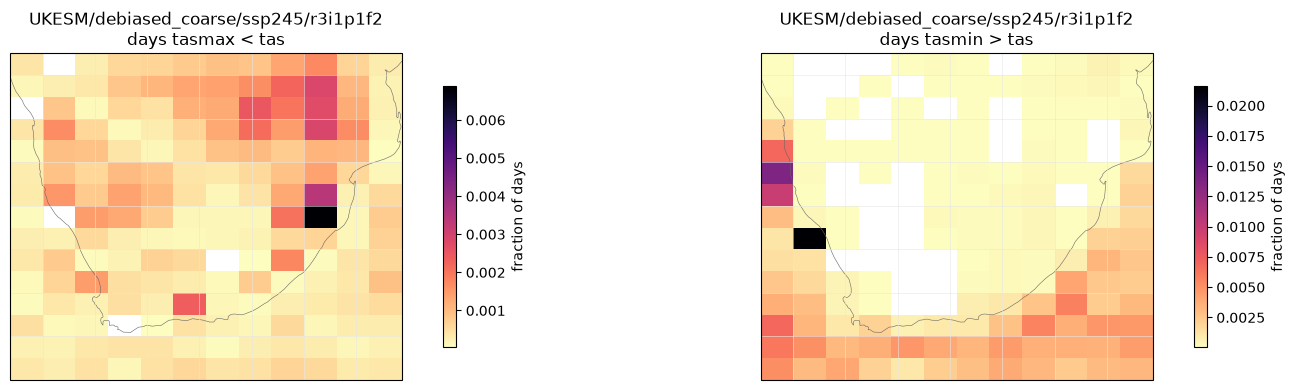

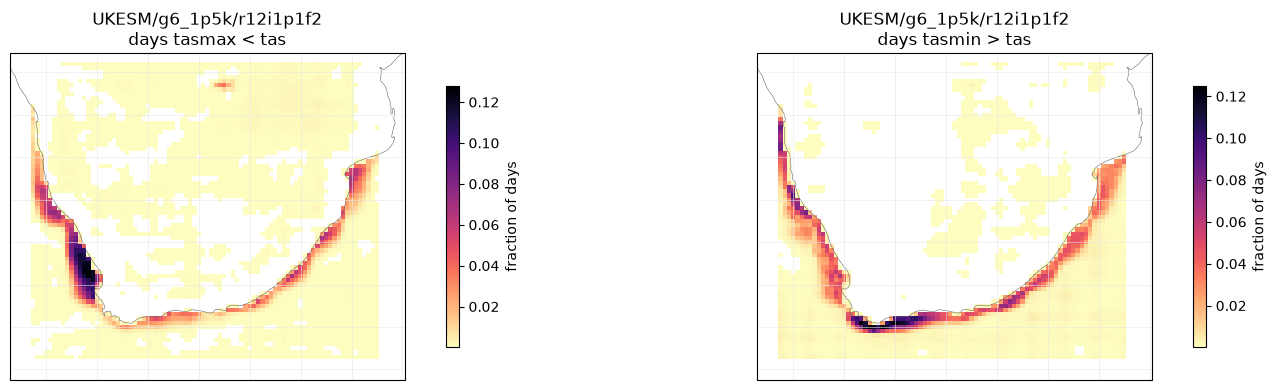

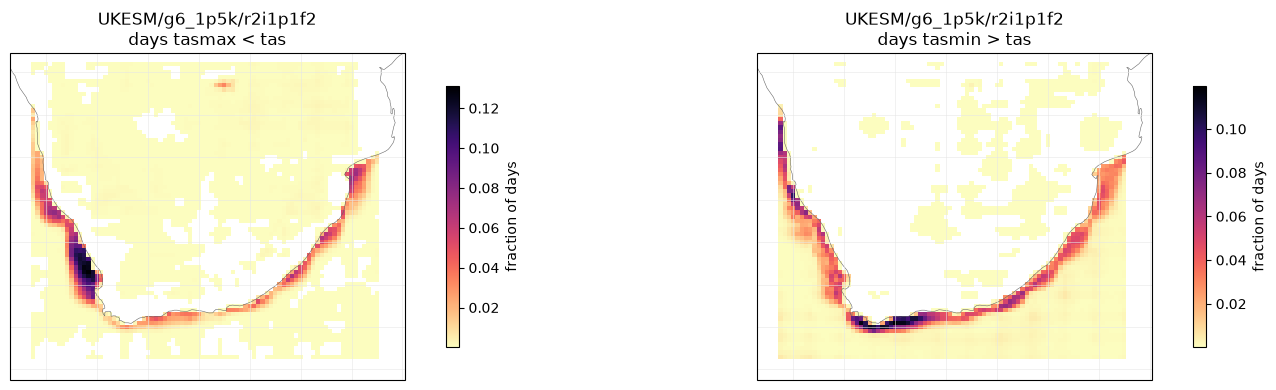

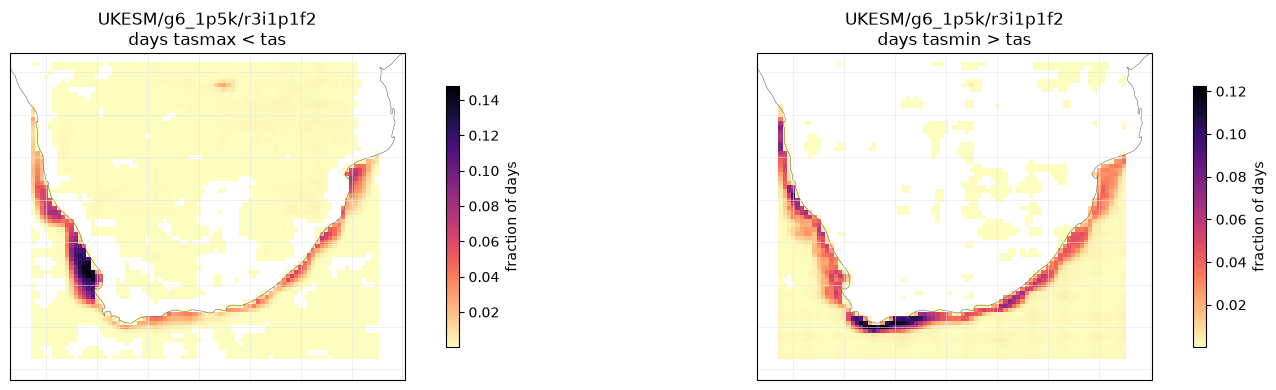

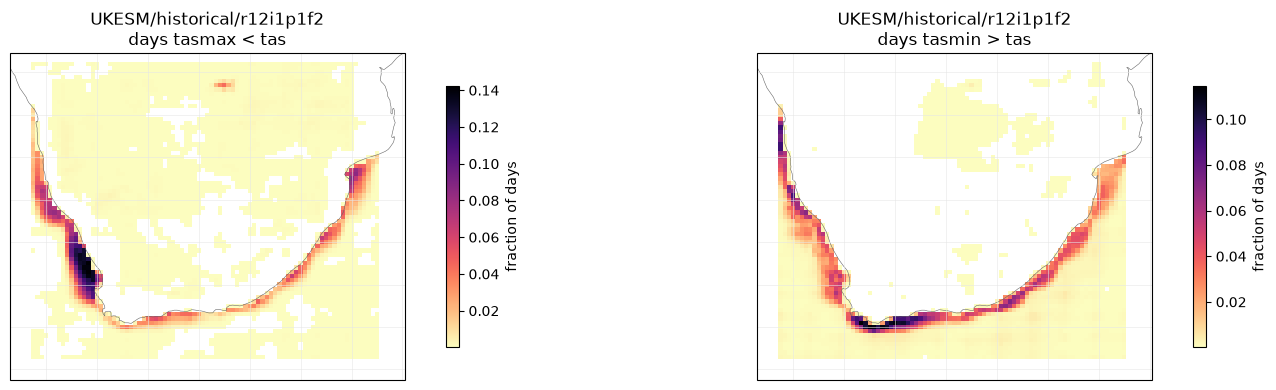

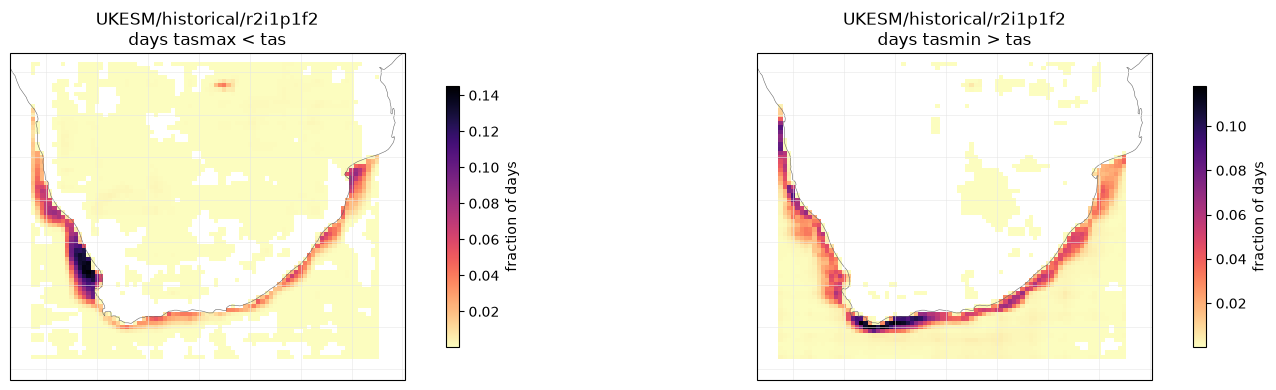

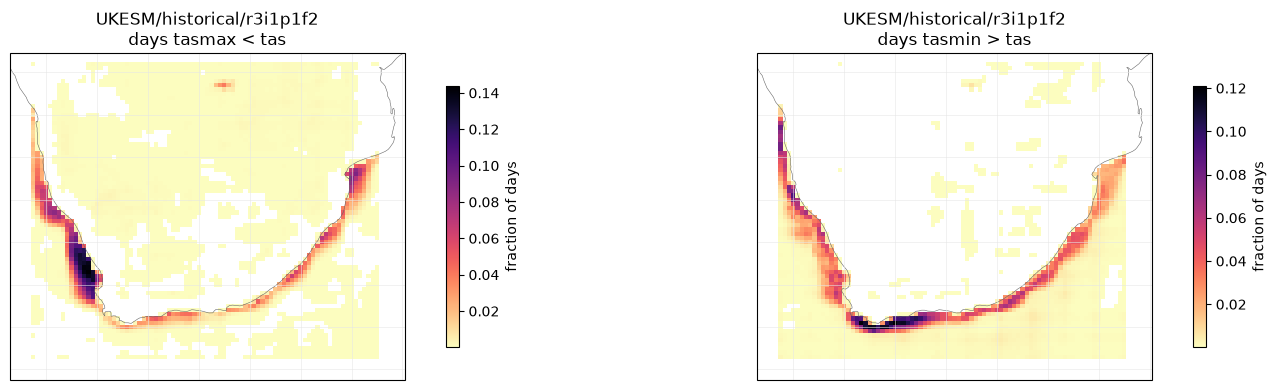

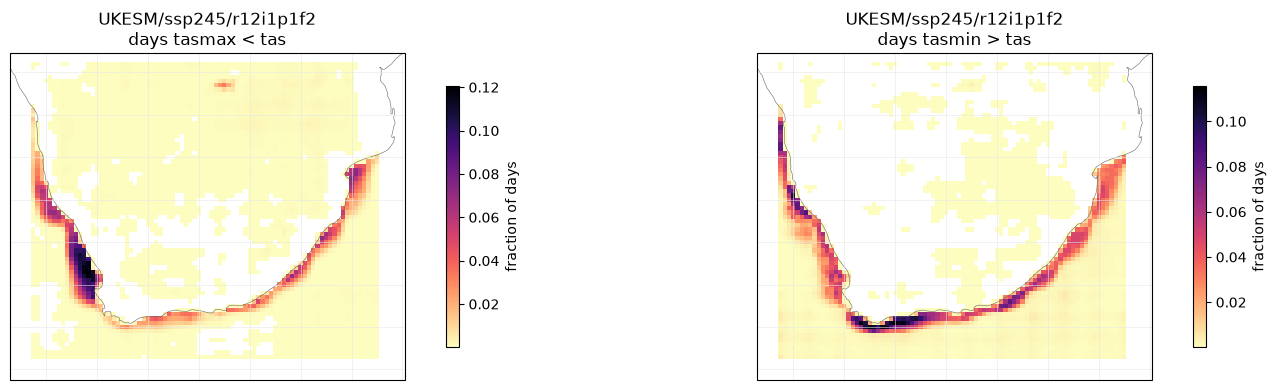

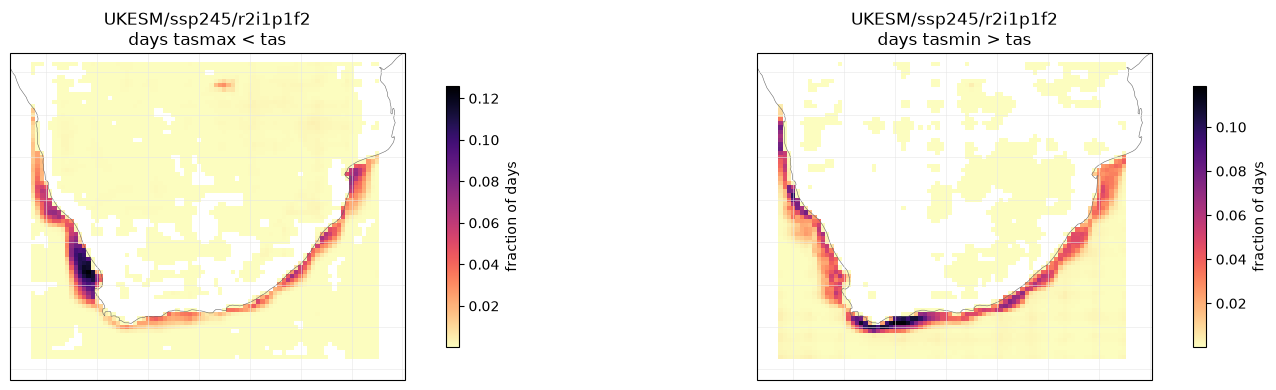

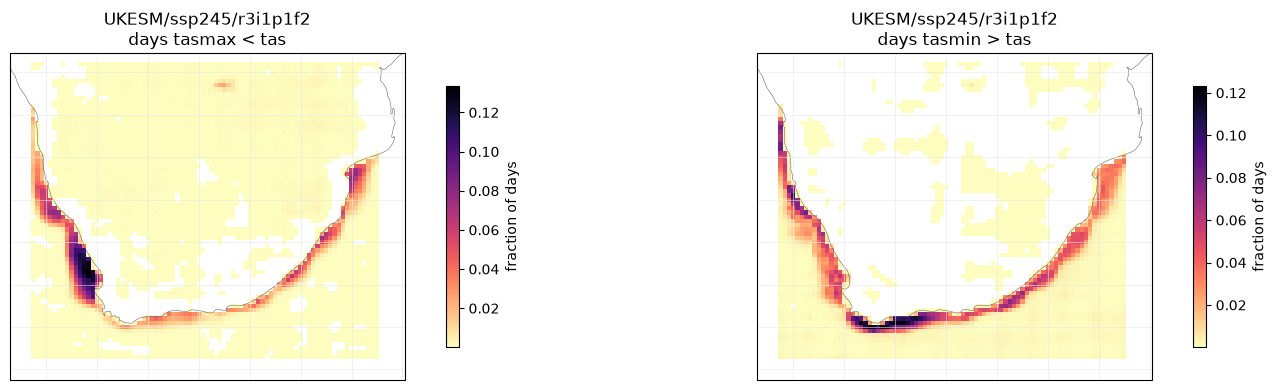

In [22]:
def plot_violation_maps(viol: dict) -> None:
    conds = [("max_lt_tas", "days tasmax < tas"), ("min_gt_tas", "days tasmin > tas")]
    for (gcm, group, m), ds in viol.items():
        n_time = ds.attrs["n_time"]
        fig, axes = plt.subplots(
            1, 2, figsize=(16, 4), subplot_kw={"projection": ccrs.PlateCarree()}
        )
        for ax, (cond, title) in zip(axes, conds):
            frac = (ds[cond] / n_time).where(ds[cond] > 0)
            frac.plot(
                ax=ax,
                transform=ccrs.PlateCarree(),
                cmap="magma_r",
                cbar_kwargs={"label": "fraction of days", "shrink": 0.8},
            )
            ax.add_feature(cfeature.COASTLINE, linewidth=0.4, edgecolor="0.4")
            ax.gridlines(draw_labels=False, color="0.9", linewidth=0.4)
            ax.set_title(f"{gcm}/{group}/{m}\n{title}")
        plt.tight_layout()
        plt.show()


plot_violation_maps(viol)

### Land, ocean, and high latitudes

Production's stratification, unchanged: five regions (global, land, ocean, land/ocean below 60°,
poleward of 60°), area-weighted by cos(latitude) on a Natural Earth land mask of cell centers.

No polar cells here, so `|lat|>=60` is empty and `|lat|<60` matches its parent. The land/ocean split
is meaningful on this box, unlike the earlier one.

In [23]:
# Land/ocean and high-latitude stratification of the Part-2 counts: post-processing of the
# per-cell counts already in `viol`, so no further reads. Unchanged from production.
_LAND_MASKS: dict[tuple[int, int], xr.DataArray] = {}


@functools.cache
def _land_polygons():
    """Union of the Natural Earth 50 m land polygons, cached for the session."""
    path = shpreader.natural_earth(resolution="50m", category="physical", name="land")
    return shapely.union_all(list(shpreader.Reader(path).geometries()))


def land_mask(template: xr.DataArray) -> xr.DataArray:
    """Boolean mask on template's grid, True where the cell center falls on land.

    Natural Earth rather than the pipeline's ocean mask, which has no Antarctica and rasterizes
    with all_touched=True. Cached per grid shape, since families and GCM grids differ.
    """
    key = (template.sizes["lat"], template.sizes["lon"])
    if key not in _LAND_MASKS:
        lon, lat = np.meshgrid(template["lon"].values, template["lat"].values)
        _LAND_MASKS[key] = xr.DataArray(
            shapely.contains_xy(_land_polygons(), lon, lat),
            coords={"lat": template["lat"], "lon": template["lon"]},
            dims=("lat", "lon"),
        )
    return _LAND_MASKS[key]


def regions_for(land: xr.DataArray) -> dict[str, xr.DataArray]:
    """Boolean region selectors on the land mask's grid, in reporting order."""
    abslat = np.abs(land["lat"])
    everywhere = xr.ones_like(land)
    return {
        "global": everywhere,
        "land": land,
        "ocean": ~land,
        "land |lat|<60": land & (abslat < 60),
        "ocean |lat|<60": ~land & (abslat < 60),
        "|lat|>=60": everywhere & (abslat >= 60),
    }


CONDS = {"max<tas": "max_lt_tas", "min>tas": "min_gt_tas"}


def regional_consistency_summary(viol: dict) -> pd.DataFrame:
    """Violation statistics per triplet and region, area-weighted by cos(lat)."""
    rows = {}
    for (gcm, group, member), ds in viol.items():
        counts = ds["max_lt_tas"]
        land = land_mask(counts)
        weights = np.cos(np.deg2rad(ds["lat"])).broadcast_like(counts)
        n_time = ds.attrs["n_time"]
        for name, sel in regions_for(land).items():
            w = weights.where(sel, 0.0)
            row = {"area_frac": round(float(w.sum() / weights.sum()), 4)}
            for label, cond in CONDS.items():
                ever = (ds[cond] > 0).astype("float32")
                freq = ds[cond] / n_time
                row[f"frac_area_ever_{label}"] = round(float(ever.weighted(w).mean(SPATIAL)), 5)
                row[f"mean_freq_{label}"] = round(float(freq.weighted(w).mean(SPATIAL)), 6)
            row["days_max<min"] = int(ds["max_lt_min"].where(sel, 0).sum())
            rows[(gcm, group, member, name)] = row
    # Build the MultiIndex explicitly (see `table`'s docstring).
    df = pd.DataFrame.from_dict(rows, orient="index")
    df.index = pd.MultiIndex.from_tuples(rows.keys(), names=["gcm", "group", "member", "region"])
    return df


regional_df = regional_consistency_summary(viol)
display(highlight(regional_df))

# How many times more often a unit of ocean area breaks the ordering than a unit of land area.
# "land 0" means the ordering never broke over land.
print("\nocean:land ratio of mean violation frequency")
for gcm, group, member in viol:
    parts = []
    for label in CONDS:
        over_land = regional_df.loc[(gcm, group, member, "land"), f"mean_freq_{label}"]
        over_ocean = regional_df.loc[(gcm, group, member, "ocean"), f"mean_freq_{label}"]
        parts.append(f"{label}: {over_ocean / over_land:.1f}x" if over_land else f"{label}: land 0")
    print(f"  {gcm}/{group}/{member}  " + "   ".join(parts))

/opt/coiled/env/lib/python3.13/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)



ocean:land ratio of mean violation frequency
  CESM2-WACCM/debiased_coarse/g6_1p5k/001  max<tas: 20.0x   min>tas: 39.7x
  CESM2-WACCM/debiased_coarse/g6_1p5k/002  max<tas: 17.1x   min>tas: 61.9x
  CESM2-WACCM/debiased_coarse/g6_1p5k/003  max<tas: 8.7x   min>tas: 51.5x
  CESM2-WACCM/debiased_coarse/g6_1p5k_end/002  max<tas: 16.0x   min>tas: 76.9x
  CESM2-WACCM/debiased_coarse/ssp245/006  max<tas: 20.5x   min>tas: 36.8x
  CESM2-WACCM/debiased_coarse/ssp245/007  max<tas: 14.6x   min>tas: 50.4x
  CESM2-WACCM/debiased_coarse/ssp245/008  max<tas: 7.4x   min>tas: 45.5x
  CESM2-WACCM/debiased_coarse/ssp245/009  max<tas: 14.8x   min>tas: 52.0x
  CESM2-WACCM/debiased_coarse/ssp245/010  max<tas: 8.3x   min>tas: 42.4x
  CESM2-WACCM/g6_1p5k/001  max<tas: 38.1x   min>tas: 120.8x
  CESM2-WACCM/g6_1p5k/002  max<tas: 34.7x   min>tas: 183.6x
  CESM2-WACCM/g6_1p5k/003  max<tas: 26.1x   min>tas: 136.0x
  CESM2-WACCM/g6_1p5k_end/002  max<tas: 32.0x   min>tas: 206.7x
  CESM2-WACCM/ssp245/006  max<tas: 41.0

Production's ratios (7-8x ocean:land for `tasmin > tas`, poleward concentration for `tasmax < tas`)
came from a full-globe read and don't transfer here. Read the `mean_freq_*` and `frac_area_ever_*`
columns above directly.

The box does show the ocean half of that pattern: `frac_area_ever_min>tas` reaches 1.00 over ocean
in every triplet against 0.6-0.9 on land, and `mean_freq_min>tas` runs two orders of magnitude
higher. Violations track surface type rather than grid artifacts, consistent with `tasmin` being
bias-corrected from `dtr` and then downscaled, where the small diurnal range over water leaves least
room. The direct test, violation frequency against per-cell `dtr`, is not run here.

## Part 3: precipitation physical constraints (issue #459)

`pr` must never go negative, and no day may carry an outlandishly large total ([#459](https://github.com/carbonplan/srm-downscaling/issues/459)). Both
are counted per cell in the Part-1 pass, so this section only summarizes and maps.

In [24]:
def pr_physical_summary(phys: dict) -> pd.DataFrame:
    """One row per pr leaf: negative and outlandish-high day/cell tallies."""
    rows = {}
    for (gcm, group, _v, m), ds in phys.items():
        rows[(gcm, group, m)] = {
            "n_time": ds.attrs["n_time"],
            "neg_cell_days": int(ds.neg_days.sum()),
            "cells_with_neg": int((ds.neg_days > 0).sum()),
            "frac_cells_neg": round(float((ds.neg_days > 0).mean()), 5),
            "high_cell_days": int(ds.high_days.sum()),
            "cells_with_high": int((ds.high_days > 0).sum()),
        }
    # Build the MultiIndex explicitly (see `table`'s docstring).
    df = pd.DataFrame.from_dict(rows, orient="index")
    df.index = pd.MultiIndex.from_tuples(rows.keys(), names=["gcm", "group", "member"])
    return df


pr_physical_df = pr_physical_summary(pr_phys)
display(highlight(pr_physical_df))

n_neg = int(pr_physical_df["neg_cell_days"].sum())
n_high = int(pr_physical_df["high_cell_days"].sum())
print(f"\nNon-negativity holds everywhere (pr >= 0): {n_neg == 0} (negative cell-days: {n_neg})")
print(f"No outlandish daily totals: {n_high == 0} (outlandish cell-days: {n_high})")


Non-negativity holds everywhere (pr >= 0): True (negative cell-days: 0)
No outlandish daily totals: True (outlandish cell-days: 0)


In [25]:
def plot_negativity_maps(phys: dict) -> None:
    """Map the fraction of days pr < 0, for any leaf that ever goes negative."""
    plotted = False
    for (gcm, group, _v, m), ds in phys.items():
        if int((ds.neg_days > 0).sum()) == 0:
            continue
        plotted = True
        frac = (ds.neg_days / ds.attrs["n_time"]).where(ds.neg_days > 0)
        fig, ax = plt.subplots(figsize=(8, 4), subplot_kw={"projection": ccrs.PlateCarree()})
        frac.plot(
            ax=ax,
            transform=ccrs.PlateCarree(),
            cmap="magma_r",
            cbar_kwargs={"label": "fraction of days pr < 0", "shrink": 0.8},
        )
        ax.add_feature(cfeature.COASTLINE, linewidth=0.4, edgecolor="0.4")
        ax.gridlines(draw_labels=False, color="0.9", linewidth=0.4)
        ax.set_title(f"{gcm}/{group}/{m}\nnegative precipitation")
        plt.tight_layout()
        plt.show()
    if not plotted:
        print("No leaf has any negative precipitation — nothing to map.")


def pr_high_days(fp: xr.DataArray) -> list[tuple[str, float]]:
    """(date, kg m-2 s-1) for days whose spatial-max pr exceeds the outlandish threshold."""
    smax = fp.sel(stat="max")
    bad = (smax > PR_OUTLANDISH).values
    return [(str(t)[:10], float(x)) for t, x in zip(fp.time.values[bad], smax.values[bad])]


plot_negativity_maps(pr_phys)

# Report-only, over the Part-1 fingerprints, restricted to pr leaves.
flagged = {k: pr_high_days(s.fingerprint) for k, s in stats.items() if k[2] == "pr"}
flagged = {k: days for k, days in flagged.items() if days}
if flagged:
    print("Outlandish precip days (report-only, spatial max > 2000 mm/day):")
    for (gcm, s, v, m), days in flagged.items():
        print(f"  {gcm}/{s}/{v}/{m}: {len(days)} days")
        for date, val in days:
            print(f"    {date}  {val:.3e} kg m-2 s-1 ({val * 86400:.0f} mm/day)")
else:
    print("No outlandish precip days flagged.")

No leaf has any negative precipitation — nothing to map.
No outlandish precip days flagged.


## Summary

Production's three parts, run per GCM against the regional (wide) run instead of one full-globe
store.

**Part 1** (#450): production's five checks plus five specific to this notebook. Expect Check 1 to
fail on every fine-grid leaf and Checks 2/5 to flag any `pr` leaf with a domain-wide dry day; 1b, 3,
4 and 7-9 should pass.

| Check | Asserts |
| --- | --- |
| 1b | No NaN outside the border shared by every leaf on a grid. Replaces Check 1 in the headline. |
| 6 | No two leaves in a `(gcm, family)` share a fingerprint over the window they share. Spans scenarios, so a bridged or branched leaf surfaces as a partial-window pair. |
| 7 | Observed `(variable, member)` leaves match `EXPECTED`, and each store's groups match the ones expected for that GCM. Only `CESM2-WACCM` carries `g6_1p5k_end`. |
| 8 | One 1-day step per leaf, catching gaps and repeats inside the window Check 4's endpoints cannot see. |
| 9 | One grid per `(gcm, family)`, with the fine family on the run's `subset_bounds`. |

**Part 2** (#448): `tasmin ≤ tas ≤ tasmax` per `(gcm, group, member)` triplet. `tasmax ≥ tasmin`
should hold everywhere (#331); the other two are diagnostic. MIROC-ES2H and UKESM surface historical
triplets that CESM2-WACCM cannot, the land/ocean split is meaningful on this box, and `|lat|>=60`
stays empty.

**Part 3** (#459): precipitation non-negativity and outlandish daily totals, per `pr` leaf.

In [26]:
cluster.shutdown()

2026-08-07 21:36:31,966 - distributed.deploy.adaptive - INFO - Adaptive scaling stopped: minimum=4 maximum=20. Reason: unknown
